# Order Flow Imbalance - MOEX AlgoPack

Intraday signal study using MOEX AlgoPack Super Candles (5-min bars): `tradestats`, `orderstats`, `obstats`. Tests whether order flow imbalance (OFI) in the first 30-60 min of the session predicts price direction over the next 1-2 hours. Includes IC analysis, simple rule-based backtest, ML walk-forward (Ridge + LightGBM), and multi-day horizon extension.

## Setup

In [33]:
import os, warnings, calendar
from pathlib import Path
from datetime import date, timedelta
from time import sleep, time

import numpy as np
import pandas as pd
import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from dotenv import load_dotenv

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({'figure.figsize': (14, 5), 'axes.grid': True, 'grid.alpha': 0.3})

load_dotenv()

TOKEN = os.getenv('MOEX_ALGOPACK_TOKEN', '')
assert TOKEN, 'Нет MOEX_ALGOPACK_TOKEN в .env'

BASE_URL = 'https://apim.moex.com/iss/datashop/algopack/eq'

ROOT      = Path('.')
CACHE_DIR = ROOT / 'data' / 'cache' / 'algopack'
for sub in ['tradestats', 'orderstats', 'obstats']:
    (CACHE_DIR / sub).mkdir(parents=True, exist_ok=True)

print('✅ Setup OK')

✅ Setup OK


In [34]:
# Конфигурация исследования
UNIVERSE = [
    'SBER', 'GAZP', 'LKOH', 'ROSN', 'NVTK', 'TATN', 'GMKN', 'MOEX', 'YNDX', 'ALRS',
    'CHMF', 'NLMK', 'PLZL', 'MGNT', 'MTSS', 'SNGS', 'AFLT', 'RUAL', 'PHOR', 'IRAO',
    'FEES', 'VTBR', 'TRNFP', 'POLY', 'MAGN', 'BSPB', 'ENRU', 'MRKS', 'MSNG', 'SELG',
    'RSTI', 'TCSG', 'RENI', 'FIVE', 'AQUA', 'MVID', 'OZON', 'QIWI', 'POSI', 'VKCO',
    'SBERP', 'TATNP', 'SNGSP', 'BANE', 'BANEP', 'LSNGP', 'LSRG', 'FESH', 'TRMK'
]
DATE_FROM  = date(2023, 1, 3)
DATE_TO    = date(2026, 6, 13)
DATE_SPLIT = date(2025, 1, 2)   # граница train/test

COST_RT    = 0.18 / 100

# FUTOI: позиции физ/юр лиц по фьючерсам -- рыночный сентимент
FUTOI_BASE_URL = 'https://apim.moex.com/iss/datashop/algopack/fo'
FUTOI_TICKERS  = ['Si', 'RI', 'BR', 'GOLD']   # USD/RUB, RTS, Brent, Gold
FUTOI_DATE_FROM = date(2020, 1, 1)             # FUTOI доступен с 2020

for sub in ['tradestats', 'orderstats', 'obstats', 'futoi']:
    (CACHE_DIR / sub).mkdir(parents=True, exist_ok=True)

print(f'Universe: {UNIVERSE}')
print(f'Train: {DATE_FROM} → {DATE_SPLIT}')
print(f'Test:  {DATE_SPLIT} → {DATE_TO}')
print(f'FUTOI: {FUTOI_TICKERS}  (с {FUTOI_DATE_FROM})')

Universe: ['SBER', 'GAZP', 'LKOH', 'ROSN', 'NVTK', 'TATN', 'GMKN', 'MOEX', 'YNDX', 'ALRS', 'CHMF', 'NLMK', 'PLZL', 'MGNT', 'MTSS', 'SNGS', 'AFLT', 'RUAL', 'PHOR', 'IRAO', 'FEES', 'VTBR', 'TRNFP', 'POLY', 'MAGN', 'BSPB', 'ENRU', 'MRKS', 'MSNG', 'SELG', 'RSTI', 'TCSG', 'RENI', 'FIVE', 'AQUA', 'MVID', 'OZON', 'QIWI', 'POSI', 'VKCO', 'SBERP', 'TATNP', 'SNGSP', 'BANE', 'BANEP', 'LSNGP', 'LSRG', 'FESH', 'TRMK']
Train: 2023-01-03 → 2025-01-02
Test:  2025-01-02 → 2026-06-13
FUTOI: ['Si', 'RI', 'BR', 'GOLD']  (с 2020-01-01)


## 1. Data Loading

API returns standard ISS JSON: `{"tradestats": {"columns": [...], "data": [[...], ...]}}`. Fetched day-by-day (<=80 bars/day) to stay within the 10K row limit. Cache: `data/cache/algopack/{metric}/{TICKER}.parquet`, incremental updates only.

In [35]:
def _make_session() -> requests.Session:
    s = requests.Session()
    s.headers.update({'Authorization': f'Bearer {TOKEN}'})
    retry = Retry(total=3, backoff_factor=2,
                  status_forcelist=[429, 500, 502, 503, 504],
                  allowed_methods=['GET'])
    s.mount('https://', HTTPAdapter(max_retries=retry))
    return s

SESSION = _make_session()


def check_auth() -> bool:
    url = f'{BASE_URL}/tradestats/sber.json'
    try:
        r = SESSION.get(url, params={'from': '2024-01-10', 'till': '2024-01-10', 'start': 0}, timeout=30)
        if 'json' in r.headers.get('Content-Type', ''):
            print('✅ Авторизация AlgoPack -- OK')
            return True
        print(f' HTTP {r.status_code}, Content-Type: {r.headers.get("Content-Type")}')
        return False
    except Exception as e:
        print(f' Нет соединения: {e}')
        return False


def _month_ranges(date_from: date, date_to: date):
    cur = date(date_from.year, date_from.month, 1)
    while cur <= date_to:
        last_day = calendar.monthrange(cur.year, cur.month)[1]
        yield max(cur, date_from), min(date(cur.year, cur.month, last_day), date_to)
        cur = date(cur.year + (cur.month == 12), (cur.month % 12) + 1, 1)


def _fetch_month(url: str, chunk_start: date, chunk_end: date) -> list[dict]:
    """
    AlgoPack: страницы по 1000 строк, курсор = [start, total, pagesize].
    Листаем start=0, 1000, 2000... пока start + len(page) < total.
    """
    all_rows = []
    start = 0
    while True:
        try:
            r = SESSION.get(url, params={'from': str(chunk_start), 'till': str(chunk_end),
                                          'start': start}, timeout=60)
        except Exception as e:
            print(f'\n    ⚠️  {chunk_start} start={start}: {type(e).__name__}')
            sleep(5)
            break

        if not r.ok or 'json' not in r.headers.get('Content-Type', ''):
            break

        try:
            payload = r.json()
        except Exception:
            break

        section = payload.get('data', {})
        cols = section.get('columns', [])
        rows = section.get('data', [])
        if not cols or not rows:
            break

        page_rows = [dict(zip(cols, row)) for row in rows]
        all_rows.extend(page_rows)

        # Курсор: [current_start, total_rows, page_size]
        cursor = payload.get('data.cursor', {}).get('data', [[0, 0, 0]])[0]
        total = int(cursor[1]) if len(cursor) > 1 else 0

        if start + len(page_rows) >= total:
            break

        start += len(page_rows)
        sleep(0.15)

    return all_rows


def _append_parquet(path: Path, new_df: pd.DataFrame) -> pd.DataFrame:
    if path.exists() and path.stat().st_size > 0:
        existing = pd.read_parquet(path)
        combined = pd.concat([existing, new_df], ignore_index=True)
        combined = combined.drop_duplicates('ts').sort_values('ts').reset_index(drop=True)
    else:
        combined = new_df.sort_values('ts').reset_index(drop=True)
    combined.to_parquet(path, index=False)
    return combined


def download_metric(ticker: str, metric: str, date_from: date, date_to: date,
                    cache_path: Path, api_base: str = None) -> pd.DataFrame:
    base = api_base or BASE_URL
    url  = f'{base}/{metric}/{ticker.lower()}.json'
    accumulated = pd.DataFrame()
    months = list(_month_ranges(date_from, date_to))
    t0 = time()

    for i, (chunk_start, chunk_end) in enumerate(months):
        rows = _fetch_month(url, chunk_start, chunk_end)

        if rows:
            df_chunk = pd.DataFrame(rows)
            if 'tradedate' in df_chunk.columns and 'tradetime' in df_chunk.columns:
                df_chunk['ts'] = pd.to_datetime(
                    df_chunk['tradedate'].astype(str) + ' ' + df_chunk['tradetime'].astype(str))
            df_chunk['ticker'] = ticker
            accumulated = _append_parquet(cache_path, df_chunk)

        elapsed = time() - t0
        eta = elapsed / (i + 1) * (len(months) - i - 1)
        print(f'    {chunk_start:%Y-%m}: {len(rows):5d} строк  '
              f'[{i+1}/{len(months)}]  ETA {eta:.0f}s     ', end='\r')
        sleep(0.3)

    print()
    return accumulated


def load_cached(ticker: str, metric: str, date_from: date, date_to: date,
                api_base: str = None) -> pd.DataFrame:
    sub  = 'futoi' if (api_base and 'fo' in api_base) else metric
    path = CACHE_DIR / sub / f'{ticker}.parquet'

    if path.exists() and path.stat().st_size > 0:
        existing = pd.read_parquet(path)
        existing['ts'] = pd.to_datetime(existing['ts'])
        last = existing['ts'].max().date() if not existing.empty else date_from - timedelta(1)

        if last >= date_to:
            mask = (existing['ts'].dt.date >= date_from) & (existing['ts'].dt.date <= date_to)
            return existing[mask].reset_index(drop=True)

        tail_from = last + timedelta(1)
        n = sum(1 for _ in _month_ranges(tail_from, date_to))
        print(f'  {ticker}/{sub}: докачка {tail_from} → {date_to} ({n} мес.)')
        download_metric(ticker, metric, tail_from, date_to, path, api_base)
        updated = pd.read_parquet(path)
        updated['ts'] = pd.to_datetime(updated['ts'])
        mask = (updated['ts'].dt.date >= date_from) & (updated['ts'].dt.date <= date_to)
        return updated[mask].reset_index(drop=True)

    n = sum(1 for _ in _month_ranges(date_from, date_to))
    print(f'  {ticker}/{sub}: полная загрузка {date_from} → {date_to} ({n} мес.)')
    df = download_metric(ticker, metric, date_from, date_to, path, api_base)
    if df.empty:
        return pd.DataFrame()
    mask = (df['ts'].dt.date >= date_from) & (df['ts'].dt.date <= date_to)
    return df[mask].reset_index(drop=True)


print('Функции загрузки готовы.')

Функции загрузки готовы.


In [32]:
# Первый раз: ~2–3 часа (Super Candles × 10 тикеров + FUTOI × 4 фьючерса)
# Повторные запуски: секунды (только хвост докачивается)

if not check_auth():
    raise SystemExit('Остановка -- исправьте токен в .env и перезапустите ячейку.')

# 1. Super Candles (акции)
tradestats, orderstats, obstats = {}, {}, {}
total_eq = len(UNIVERSE) * 3
done = 0

print('=' * 55)
print('ЧАСТЬ 1/2: Super Candles (акции)')
print('=' * 55)

for ticker in UNIVERSE:
    print(f'\n── {ticker} ──────────────────────────────────')
    tradestats[ticker] = load_cached(ticker, 'tradestats', DATE_FROM, DATE_TO); done += 1
    orderstats[ticker] = load_cached(ticker, 'orderstats', DATE_FROM, DATE_TO); done += 1
    obstats[ticker]    = load_cached(ticker, 'obstats',    DATE_FROM, DATE_TO); done += 1
    print(f'  → ts={len(tradestats[ticker]):,}  os={len(orderstats[ticker]):,}  ob={len(obstats[ticker]):,}'
          f'  [{done}/{total_eq}]')

# ── 2. FUTOI (фьючерсы) ───────────────────────────────────────────────
futoi = {}

print('\n' + '=' * 55)
print('ЧАСТЬ 2/2: FUTOI (позиции физ/юр по фьючерсам, с 2020)')
print('=' * 55)

for ticker in FUTOI_TICKERS:
    print(f'\n── {ticker} ──────────────────────────────────')
    futoi[ticker] = load_cached(ticker, 'futoi', FUTOI_DATE_FROM, DATE_TO,
                                api_base=FUTOI_BASE_URL)
    print(f'  → {len(futoi[ticker]):,} строк')

print('\n✅ Вся загрузка завершена')
print(f'   Super Candles: {sum(len(v) for v in tradestats.values()):,} строк (tradestats)')
print(f'   FUTOI:         {sum(len(v) for v in futoi.values()):,} строк')

✅ Авторизация AlgoPack — OK
ЧАСТЬ 1/2: Super Candles (акции)

── SBER ──────────────────────────────────
  → ts=164,064  os=165,048  ob=164,053  [3/147]

── GAZP ──────────────────────────────────
  → ts=164,556  os=165,083  ob=164,089  [6/147]

── LKOH ──────────────────────────────────
  → ts=164,406  os=165,046  ob=164,053  [9/147]

── ROSN ──────────────────────────────────
  → ts=164,085  os=165,010  ob=164,017  [12/147]

── NVTK ──────────────────────────────────
  → ts=163,803  os=164,615  ob=163,621  [15/147]

── TATN ──────────────────────────────────
  → ts=163,810  os=164,792  ob=163,801  [18/147]

── GMKN ──────────────────────────────────
  → ts=163,885  os=164,425  ob=163,430  [21/147]

── MOEX ──────────────────────────────────
  → ts=164,211  os=164,989  ob=164,053  [24/147]

── YNDX ──────────────────────────────────
  YNDX/tradestats: докачка 2024-06-15 → 2026-06-13 (25 мес.)
    2026-06:     0 строк  [25/25]  ETA 0s     
  YNDX/orderstats: докачка 2024-06-15 → 2026-0

In [36]:
# Смотрим структуру колонок -- важно для построения фичей
for metric, store in [('tradestats', tradestats), ('orderstats', orderstats), ('obstats', obstats)]:
    for t, df in store.items():
        if not df.empty:
            print(f'{metric} [{t}] cols: {df.columns.tolist()}')
            print(f'  sample: {df.iloc[0].to_dict()}')
            break

tradestats [SBER] cols: ['tradedate', 'tradetime', 'secid', 'pr_open', 'pr_high', 'pr_low', 'pr_close', 'pr_std', 'vol', 'val', 'trades', 'pr_vwap', 'pr_change', 'trades_b', 'trades_s', 'val_b', 'val_s', 'vol_b', 'vol_s', 'disb', 'pr_vwap_b', 'pr_vwap_s', 'SYSTIME', 'sec_pr_open', 'sec_pr_high', 'sec_pr_low', 'sec_pr_close', 'ts', 'ticker']
  sample: {'tradedate': '2023-01-03', 'tradetime': '10:05:00', 'secid': 'SBER', 'pr_open': 141.6, 'pr_high': 142.0, 'pr_low': 141.56, 'pr_close': 141.74, 'pr_std': 0.0001, 'vol': 97260, 'val': 137871991, 'trades': 2125, 'pr_vwap': 141.76, 'pr_change': 0.0989, 'trades_b': 1185, 'trades_s': 940, 'val_b': 76441036, 'val_s': 61430954, 'vol_b': 53913, 'vol_s': 43347, 'disb': 0.11, 'pr_vwap_b': 141.79, 'pr_vwap_s': 141.72, 'SYSTIME': '2024-08-12 00:36:13', 'sec_pr_open': 1.0, 'sec_pr_high': 44.0, 'sec_pr_low': 212.0, 'sec_pr_close': 300.0, 'ts': Timestamp('2023-01-03 10:05:00'), 'ticker': 'SBER'}
orderstats [SBER] cols: ['tradedate', 'tradetime', 'secid',

## 2. Feature Engineering

In [37]:
SESSION_START = '10:05'
SESSION_END   = '18:35'
HOLD_PERIODS  = [6, 9, 12, 18]   # 30 / 45 / 60 / 90 мин

def safe_div(a, b, fill=0.0):
    b = np.where(b == 0, np.nan, b)
    return np.where(np.isnan(b), fill, a / b)


def build_features(ticker: str) -> pd.DataFrame:
    ts_df = tradestats.get(ticker, pd.DataFrame())
    os_df = orderstats.get(ticker, pd.DataFrame())
    ob_df = obstats.get(ticker,    pd.DataFrame())
    if ts_df.empty:
        return pd.DataFrame()

    df = ts_df.copy().set_index('ts').sort_index()
    if not os_df.empty:
        df = df.join(os_df.set_index('ts'), how='left', rsuffix='_ord')
    if not ob_df.empty:
        df = df.join(ob_df.set_index('ts'), how='left', rsuffix='_ob')
    df = df.reset_index()
    df['ticker'] = ticker

    t_str = df['ts'].dt.strftime('%H:%M')
    df = df[(t_str >= SESSION_START) & (t_str <= SESSION_END)].copy()
    df = df.sort_values('ts').reset_index(drop=True)
    df['date'] = df['ts'].dt.date

    # ── Базовые сигналы ────────────────────────────────────────────────
    # TFI
    if 'disb' in df.columns:
        df['tfi'] = pd.to_numeric(df['disb'], errors='coerce').fillna(0)
    else:
        df['tfi'] = np.nan

    # OFI
    if 'put_vol_b' in df.columns:
        nb = pd.to_numeric(df['put_vol_b'], errors='coerce').fillna(0) - \
             pd.to_numeric(df['cancel_vol_b'], errors='coerce').fillna(0)
        ns = pd.to_numeric(df['put_vol_s'], errors='coerce').fillna(0) - \
             pd.to_numeric(df['cancel_vol_s'], errors='coerce').fillna(0)
        df['ofi'] = safe_div(nb - ns, nb.abs() + ns.abs())
    else:
        df['ofi'] = np.nan

    # OB Imbalance (BBO level -- самый чистый)
    if 'imbalance_vol_bbo' in df.columns:
        df['ob_imb'] = pd.to_numeric(df['imbalance_vol_bbo'], errors='coerce').fillna(0)
    else:
        df['ob_imb'] = np.nan

    # VWAP spread
    if 'pr_vwap_b' in df.columns and 'pr_vwap_s' in df.columns:
        vb = pd.to_numeric(df['pr_vwap_b'], errors='coerce')
        vs = pd.to_numeric(df['pr_vwap_s'], errors='coerce')
        df['vwap_spread'] = safe_div(vb - vs, (vb + vs) / 2)
    else:
        df['vwap_spread'] = np.nan

    # ── Сглаживание: raw / r3 / r5 / ewm5 ────────────────────────────
    for col in ['tfi', 'ofi', 'ob_imb', 'vwap_spread']:
        if col not in df.columns or df[col].isna().all():
            continue
        g = df.groupby('date')[col]
        df[f'{col}_r3']   = g.transform(lambda x: x.rolling(3, min_periods=2).mean())
        df[f'{col}_r5']   = g.transform(lambda x: x.rolling(5, min_periods=3).mean())
        df[f'{col}_ewm5'] = g.transform(lambda x: x.ewm(span=5, adjust=False).mean())

    # ── Цены ──────────────────────────────────────────────────────────
    if 'pr_close' in df.columns:
        df['price'] = pd.to_numeric(df['pr_close'], errors='coerce')
    if 'pr_open' in df.columns:
        df['open_price'] = pd.to_numeric(df['pr_open'], errors='coerce')
        # entry_px = открытие СЛЕДУЮЩЕГО бара (нет look-ahead bias)
        df['entry_px'] = df.groupby('date')['open_price'].transform(lambda x: x.shift(-1))
        # open_ret_N = доходность от entry_px до открытия бара через N шагов
        for n in HOLD_PERIODS:
            df[f'open_ret_{n}'] = df.groupby('date')['open_price'].transform(
                lambda x, n=n: x.shift(-(n + 1)) / x.shift(-1) - 1
            )

    # ── Forward returns close→close (для IC анализа) ──────────────────
    if 'price' in df.columns:
        for n in [1, 3, 6, 12, 18]:
            df[f'fret_{n}'] = df.groupby('date')['price'].transform(
                lambda x: x.shift(-n) / x - 1)

    if 'vol' in df.columns:
        df = df[pd.to_numeric(df['vol'], errors='coerce').fillna(0) > 0].copy()

    return df


# ── Строим фичи ────────────────────────────────────────────────────────
print('Строим фичи...')
features = {}
for ticker in UNIVERSE:
    f = build_features(ticker)
    if not f.empty:
        features[ticker] = f
        print(f'  {ticker}: {len(f):,} баров, {f["date"].nunique()} дней')
    else:
        print(f'  {ticker}: нет данных')

all_feat = pd.concat(features.values(), ignore_index=True)
all_feat['ts'] = pd.to_datetime(all_feat['ts'])

# ── Market-neutral: вычитаем среднее по юниверсу в каждый timestamp ──
for col in [c for c in all_feat.columns if c.startswith('fret_') and '_mn' not in c]:
    mkt = all_feat.groupby('ts')[col].transform('mean')
    all_feat[f'{col}_mn'] = all_feat[col] - mkt

# Записываем market-neutral версии обратно в features dict
for ticker in features:
    mask = all_feat['ticker'] == ticker
    mn_cols = [c for c in all_feat.columns if c.endswith('_mn')]
    features[ticker] = features[ticker].merge(
        all_feat.loc[mask, ['ts'] + mn_cols], on='ts', how='left')

RAW_SIGS  = ['tfi', 'ofi', 'ob_imb', 'vwap_spread']
SMOOTH_SIGS = [f'{s}_{v}' for s in RAW_SIGS for v in ['r3', 'r5', 'ewm5']]
SIGNAL_COLS = [c for c in SMOOTH_SIGS + RAW_SIGS if c in all_feat.columns and all_feat[c].notna().any()]
FRET_COLS   = [c for c in all_feat.columns if c.startswith('fret_') and all_feat[c].notna().any()]

print(f'\nСигналов: {len(SIGNAL_COLS)}  |  Таргетов: {len(FRET_COLS)}')
print(f'Итого: {len(all_feat):,} баров × {all_feat["ticker"].nunique()} тикеров')
print(f'entry_px: {"✅" if "entry_px" in all_feat.columns else "❌"}  '
      f'open_ret: {"✅" if "open_ret_12" in all_feat.columns else "❌"}  '
      f'market-neutral: {"✅" if "fret_12_mn" in all_feat.columns else "❌"}')

Строим фичи...
  SBER: 100,369 баров, 976 дней
  GAZP: 100,369 баров, 976 дней
  LKOH: 100,369 баров, 976 дней
  ROSN: 100,369 баров, 976 дней
  NVTK: 99,957 баров, 972 дней
  TATN: 100,161 баров, 974 дней
  GMKN: 99,937 баров, 972 дней
  MOEX: 100,349 баров, 976 дней
  YNDX: 37,872 баров, 368 дней
  ALRS: 100,340 баров, 976 дней
  CHMF: 100,345 баров, 976 дней
  NLMK: 100,294 баров, 976 дней
  PLZL: 99,642 баров, 969 дней
  MGNT: 100,211 баров, 976 дней
  MTSS: 100,117 баров, 975 дней
  SNGS: 99,801 баров, 976 дней
  AFLT: 100,369 баров, 976 дней
  RUAL: 100,288 баров, 976 дней
  PHOR: 99,788 баров, 974 дней
  IRAO: 100,163 баров, 974 дней
  FEES: 98,577 баров, 970 дней
  VTBR: 99,951 баров, 972 дней
  TRNFP: 98,724 баров, 972 дней
  POLY: 41,154 баров, 400 дней
  MAGN: 100,364 баров, 976 дней
  BSPB: 99,339 баров, 972 дней
  ENRU: 5,858 баров, 57 дней
  MRKS: 68,795 баров, 966 дней
  MSNG: 95,202 баров, 976 дней
  SELG: 99,469 баров, 976 дней
  RSTI: нет данных
  TCSG: 48,029 баров, 

In [38]:
# Краткая статистика по сигналам
print(all_feat[SIGNAL_COLS + FRET_COLS[:2]].describe())

            tfi_r3       tfi_r5     tfi_ewm5       ofi_r3       ofi_r5  \
count 4317341.0000 4274243.0000 4360439.0000 4317341.0000 4274243.0000   
mean        0.0169       0.0169       0.0161      -0.0046      -0.0046   
std         0.3853       0.3216       0.3194       0.3191       0.2446   
min        -1.0000      -1.0000      -1.0000      -1.0000      -1.0000   
25%        -0.2533      -0.2000      -0.2064      -0.2090      -0.1598   
50%         0.0133       0.0140       0.0143      -0.0031      -0.0041   
75%         0.2867       0.2340       0.2375       0.1995       0.1502   
max         1.0000       1.0000       1.0000       1.0000       1.0000   

          ofi_ewm5    ob_imb_r3    ob_imb_r5  ob_imb_ewm5  vwap_spread_r3  \
count 4360439.0000 4317341.0000 4274243.0000 4360439.0000    4317341.0000   
mean       -0.0052      -0.0616      -0.0616      -0.0612          0.0004   
std         0.2498       0.2663       0.2340       0.2282          0.0005   
min        -1.0000      -

## 3. IC Analysis

IC (Information Coefficient) = Spearman correlation between signal and forward intraday return. Threshold for a tradeable signal: IC > 0.03 and t-stat > 2.0.

In [20]:
def daily_ic(df: pd.DataFrame, sig: str, fret: str) -> pd.Series:
    rows = []
    for d, sub in df.dropna(subset=[sig, fret]).groupby('date'):
        if len(sub) < 5:
            continue
        r, _ = stats.spearmanr(sub[sig], sub[fret])
        rows.append({'date': pd.Timestamp(d), 'ic': r})
    return pd.DataFrame(rows).set_index('date')['ic'] if rows else pd.Series(dtype=float)


def ic_stats(ic: pd.Series, label: str) -> dict:
    if ic.empty or len(ic) < 10:
        return {}
    t = ic.mean() / (ic.std() / np.sqrt(len(ic)))
    return {'label': label, 'mean_ic': ic.mean(), 'IR': ic.mean() / ic.std() if ic.std() else 0,
            't_stat': t, 'pct_pos': (ic > 0).mean(), 'n': len(ic)}


# ── IC по всем сигналам × таргетам (включая market-neutral) ───────────
ic_cache = {}
rows_ic = []

# Тестируем сигналы против обычных и market-neutral returns
TARGET_COLS = ['fret_6', 'fret_12', 'fret_6_mn', 'fret_12_mn']
TARGET_COLS = [c for c in TARGET_COLS if c in all_feat.columns]

for sig in SIGNAL_COLS:
    for fret in TARGET_COLS:
        key = (sig, fret)
        ic = daily_ic(all_feat, sig, fret)
        ic_cache[key] = ic
        s = ic_stats(ic, f'{sig} → {fret}')
        if s:
            rows_ic.append(s)

ic_table = pd.DataFrame(rows_ic).sort_values('t_stat', ascending=False)

# ── Топ-20 по t-stat ──────────────────────────────────────────────────
print('=== IC Summary (топ-20 по |t-stat|) ===')
print(ic_table.head(20).to_string(index=False))

# ── Лучший сигнал по mean_ic на fret_12_mn (market-neutral target) ───
mn_table = ic_table[ic_table['label'].str.contains('_mn')].sort_values('mean_ic', ascending=False)
raw_table = ic_table[~ic_table['label'].str.contains('_mn')].sort_values('mean_ic', ascending=False)

print(f'\n▸ Лучший (raw target):  {raw_table.iloc[0]["label"] if not raw_table.empty else "--"}')
print(f'▸ Лучший (MN target):   {mn_table.iloc[0]["label"] if not mn_table.empty else "--"}')

# Выбираем лучший сигнал для бэктеста (по MN если доступен)
best_row  = mn_table.iloc[0] if not mn_table.empty else ic_table.iloc[0]
BEST_SIG  = best_row['label'].split(' → ')[0]
BEST_FRET = best_row['label'].split(' → ')[1]
print(f'\nДля бэктеста: {BEST_SIG} → {BEST_FRET}  (IC={best_row["mean_ic"]:.4f}, t={best_row["t_stat"]:.2f})')

=== IC Summary (топ-20 по |t-stat|) ===
                   label  mean_ic     IR  t_stat  pct_pos   n
            ofi → fret_6   0.0161 0.4436 13.8587   0.6752 976
           ofi → fret_12   0.0162 0.4286 13.3914   0.6568 976
         ofi → fret_6_mn   0.0129 0.4139 12.9302   0.6619 976
        ofi → fret_12_mn   0.0139 0.4111 12.8440   0.6537 976
       ofi_ewm5 → fret_6   0.0220 0.3636 11.3578   0.6527 976
    ofi_ewm5 → fret_6_mn   0.0188 0.3506 10.9527   0.6332 976
   ofi_ewm5 → fret_12_mn   0.0209 0.3241 10.1240   0.6178 976
      ofi_ewm5 → fret_12   0.0226 0.3223 10.0702   0.6240 976
         ofi_r3 → fret_6   0.0179 0.3210 10.0268   0.6342 976
     ofi_r3 → fret_12_mn   0.0176 0.3169  9.8994   0.6178 976
        ofi_r3 → fret_12   0.0189 0.3115  9.7313   0.6250 976
         ofi_r5 → fret_6   0.0203 0.3083  9.6329   0.6158 976
      ofi_r5 → fret_6_mn   0.0180 0.3065  9.5761   0.6137 976
      ofi_r3 → fret_6_mn   0.0151 0.3057  9.5500   0.6250 976
     ofi_r5 → fret_12_mn   0.0

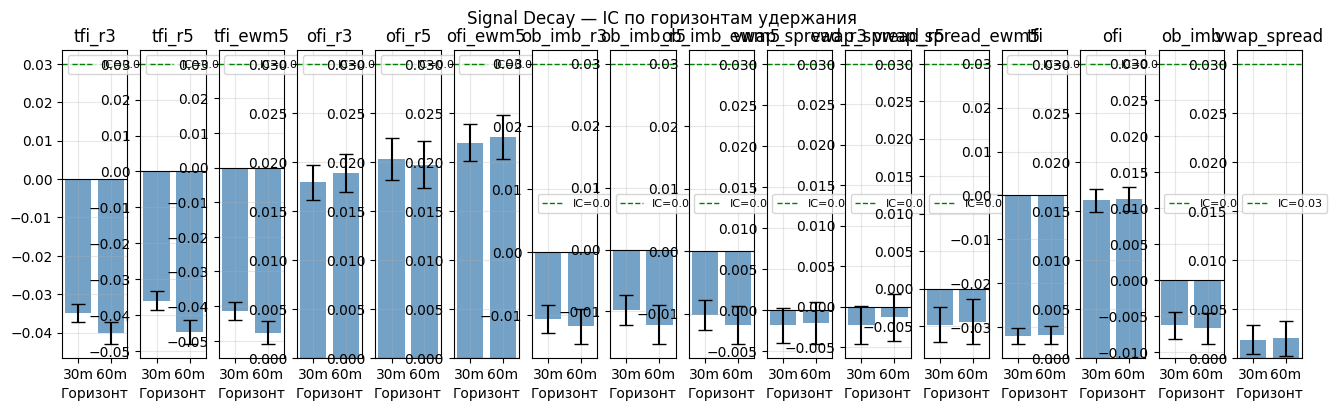

In [21]:
# ── Signal Decay: IC по горизонтам ───────────────────────────────────
horizons = [1, 3, 6, 12]  # бары × 5 мин = 5/15/30/60 мин

fig, axes = plt.subplots(1, len(SIGNAL_COLS), figsize=(16, 4), sharey=False)
if len(SIGNAL_COLS) == 1:
    axes = [axes]

for ax, sig in zip(axes, SIGNAL_COLS):
    means = [ic_cache.get((sig, f'fret_{h}'), pd.Series()).mean() for h in horizons]
    stes  = [ic_cache.get((sig, f'fret_{h}'), pd.Series()).std() /
             max(np.sqrt(len(ic_cache.get((sig, f'fret_{h}'), pd.Series()))), 1) for h in horizons]
    ax.bar([f'{h*5}m' for h in horizons], means, yerr=stes, capsize=5,
           color='steelblue', alpha=0.75)
    ax.axhline(0, color='black', lw=0.8)
    ax.axhline(0.03, color='green', lw=1, ls='--', label='IC=0.03')
    ax.set_title(sig)
    ax.set_xlabel('Горизонт')
    ax.legend(fontsize=8)

plt.suptitle('Signal Decay -- IC по горизонтам удержания')
plt.tight_layout()
plt.show()

Лучшая пара: ofi → fret_6  (IC=0.0161, t=13.86)


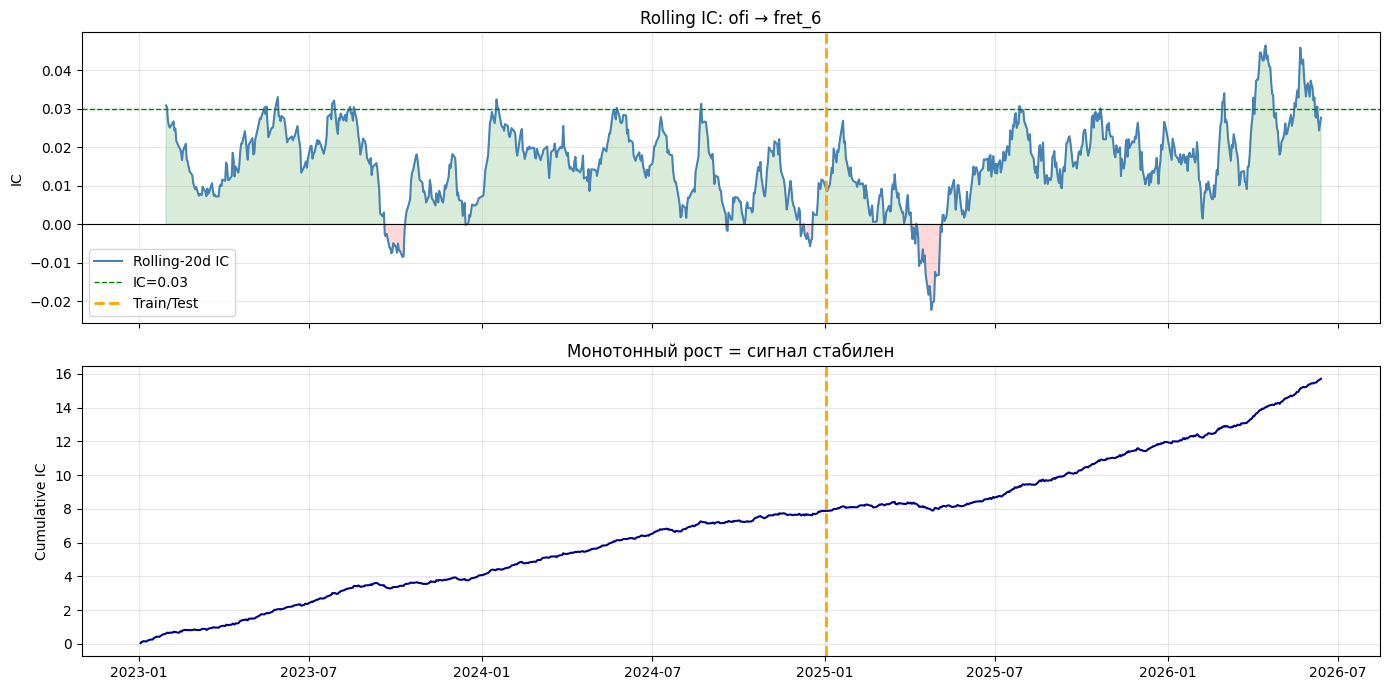

Train IC: 0.0154 | Test IC: 0.0168
Норма: Test IC не ниже Train IC более чем на 50%


In [22]:
# ── Лучший сигнал × горизонт по IC ───────────────────────────────────
if not ic_table.empty:
    best_row = ic_table.iloc[0]
    BEST_SIG  = best_row['label'].split(' → ')[0]
    BEST_FRET = best_row['label'].split(' → ')[1]
else:
    BEST_SIG, BEST_FRET = SIGNAL_COLS[0], 'fret_3'

print(f'Лучшая пара: {BEST_SIG} → {BEST_FRET}  (IC={best_row["mean_ic"]:.4f}, t={best_row["t_stat"]:.2f})')

# Rolling IC во времени
ic_best = ic_cache.get((BEST_SIG, BEST_FRET), pd.Series(dtype=float))

if not ic_best.empty:
    roll = ic_best.rolling(20).mean()
    cumul = ic_best.cumsum()

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

    ax1.plot(roll, color='steelblue', lw=1.5, label='Rolling-20d IC')
    ax1.fill_between(roll.index, roll, 0, where=roll > 0, alpha=0.15, color='green')
    ax1.fill_between(roll.index, roll, 0, where=roll < 0, alpha=0.15, color='red')
    ax1.axhline(0, color='black', lw=0.8)
    ax1.axhline(0.03, color='green', lw=1, ls='--', label='IC=0.03')
    ax1.axvline(pd.Timestamp(DATE_SPLIT), color='orange', lw=2, ls='--', label='Train/Test')
    ax1.set_ylabel('IC')
    ax1.set_title(f'Rolling IC: {BEST_SIG} → {BEST_FRET}')
    ax1.legend()

    ax2.plot(cumul, color='darkblue', lw=1.5)
    ax2.axvline(pd.Timestamp(DATE_SPLIT), color='orange', lw=2, ls='--')
    ax2.set_ylabel('Cumulative IC')
    ax2.set_title('Монотонный рост = сигнал стабилен')

    plt.tight_layout()
    plt.show()

    train_ic = ic_best[ic_best.index < pd.Timestamp(DATE_SPLIT)]
    test_ic  = ic_best[ic_best.index >= pd.Timestamp(DATE_SPLIT)]
    print(f'Train IC: {train_ic.mean():.4f} | Test IC: {test_ic.mean():.4f}')
    print('Норма: Test IC не ниже Train IC более чем на 50%')

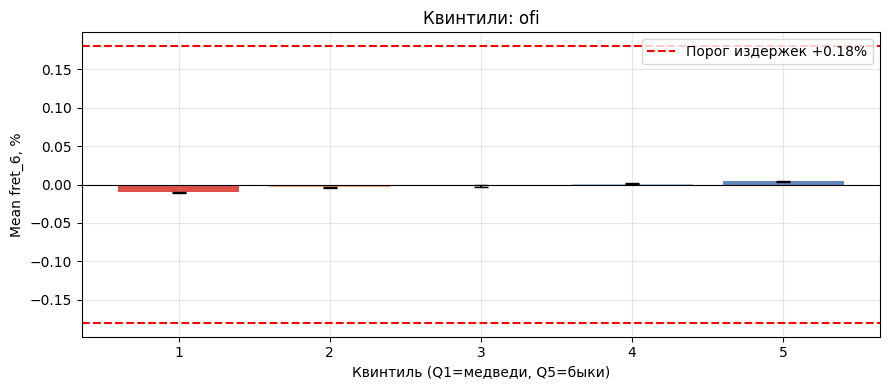

             pct     se   count
quintile                       
1.0000   -0.0098 0.0000  177298
2.0000   -0.0035 0.0000  176696
3.0000   -0.0018 0.0000  177263
4.0000    0.0008 0.0000  176695
5.0000    0.0042 0.0000  177288

Q5-Q1 spread: 0.0140%  |  net-of-cost: -0.1660%


In [23]:
# ── Квинтильный анализ ───────────────────────────────────────────────
df_q = all_feat.dropna(subset=[BEST_SIG, BEST_FRET]).copy()
df_q['quintile'] = df_q.groupby('date')[BEST_SIG].transform(
    lambda x: pd.qcut(x, 5, labels=[1,2,3,4,5], duplicates='drop')
).astype(float)
df_q = df_q.dropna(subset=['quintile'])

qsum = df_q.groupby('quintile')[BEST_FRET].agg(['mean','std','count'])
qsum['se']  = qsum['std'] / np.sqrt(qsum['count'])
qsum['pct'] = qsum['mean'] * 100

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#d73027','#fc8d59','#fee090','#91bfdb','#4575b4']
ax.bar(qsum.index, qsum['pct'], yerr=qsum['se']*100, capsize=5, color=colors, alpha=0.85)
ax.axhline(0, color='black', lw=0.8)
ax.axhline(COST_RT * 100, color='red', lw=1.5, ls='--', label=f'Порог издержек +{COST_RT*100:.2f}%')
ax.axhline(-COST_RT * 100, color='red', lw=1.5, ls='--')
ax.set_xlabel('Квинтиль (Q1=медведи, Q5=быки)')
ax.set_ylabel(f'Mean {BEST_FRET}, %')
ax.set_title(f'Квинтили: {BEST_SIG}')
ax.legend()
plt.tight_layout()
plt.show()

spread = qsum.loc[5,'pct'] - qsum.loc[1,'pct']
print(qsum[['pct','se','count']])
print(f'\nQ5-Q1 spread: {spread:.4f}%  |  net-of-cost: {spread - COST_RT*100:.4f}%')

## 4. Backtest -- Morning OFI Momentum

Rules: at 10:30, compute rolling OFI; if above threshold, enter long top-N stocks; exit after 60 min or EOD. Long-only.

In [24]:
from itertools import product as iproduct

# ── Быстрый векторизованный бэктест ───────────────────────────────────
def run_backtest_fast(sig_col: str, threshold: float, entry_time: str,
                      hold_bars: int, top_n: int, cost: float,
                      df: pd.DataFrame, date_from, date_to) -> pd.DataFrame:
    ret_col = f'open_ret_{hold_bars}'
    if ret_col not in df.columns or sig_col not in df.columns:
        return pd.DataFrame()

    mask = (
        (df['ts'].dt.strftime('%H:%M') == entry_time) &
        (df[sig_col] >= threshold) &
        df[sig_col].notna() &
        df['entry_px'].notna() &
        df[ret_col].notna() &
        (df['ts'].dt.date >= date_from) &
        (df['ts'].dt.date <= date_to)
    )
    sub = df[mask][['date', 'ticker', sig_col, 'entry_px', ret_col]].copy()
    if sub.empty:
        return pd.DataFrame()

    # top-N per day
    sub = (sub.sort_values(sig_col, ascending=False)
              .groupby('date').head(top_n)
              .copy())
    sub['ret_gross'] = sub[ret_col]
    sub['ret_net']   = sub['ret_gross'] - cost
    return sub


def perf_fast(df: pd.DataFrame, label: str, verbose=True) -> dict:
    if df.empty:
        if verbose: print(f'{label}: нет сделок')
        return {}
    r = df['ret_net']
    n_days = df['date'].nunique()
    cum = (1 + r).prod() - 1
    t, p = stats.ttest_1samp(r, 0)
    sr = r.mean() / r.std() * np.sqrt(252 * len(r) / max(n_days, 1)) if r.std() > 0 else 0
    eq = (1 + r).cumprod()
    dd = (eq / eq.cummax() - 1).min()
    res = {'n': len(r), 'cum': cum, 'mean_net': r.mean()*100,
           'win_rate': (r>0).mean(), 'sharpe': sr, 'max_dd': dd, 't': t, 'p': p}
    if verbose:
        print(f'\n=== {label} ===')
        print(f'  Сделок: {len(r)}  |  Дней: {n_days}')
        print(f'  Cumul:  {cum:.1%}  |  Mean net/trade: {r.mean()*100:.4f}%')
        print(f'  Win rate: {(r>0).mean():.1%}  |  Sharpe: {sr:.2f}  |  MaxDD: {dd:.1%}')
        print(f'  t={t:.2f}  p={p:.3f}  → {"✅" if p<0.05 and r.mean()>0 else "❌"}')
    return res


# ── Grid search на TRAIN периоде ──────────────────────────────────────
print('Grid search на TRAIN (2023–2024)...')

GRID = {
    'sig_col':    [BEST_SIG],
    'threshold':  [0.05, 0.10, 0.15, 0.20],
    'entry_time': ['10:15', '10:30', '10:45', '11:00'],
    'hold_bars':  HOLD_PERIODS,
    'top_n':      [1, 3, 5],
}

# Для grid search используем all_feat (все тикеры объединены)
grid_rows = []
combos = list(iproduct(
    GRID['sig_col'], GRID['threshold'], GRID['entry_time'],
    GRID['hold_bars'], GRID['top_n']
))

for i, (sig, thr, et, hold, tn) in enumerate(combos):
    trades = run_backtest_fast(sig, thr, et, hold, tn, COST_RT,
                               all_feat, DATE_FROM, DATE_SPLIT)
    p = perf_fast(trades, '', verbose=False)
    if p and p['n'] >= 50:
        grid_rows.append({
            'sig': sig, 'threshold': thr, 'entry': et,
            'hold_min': hold * 5, 'top_n': tn,
            **{k: round(v, 4) for k, v in p.items()}
        })
    if (i+1) % 50 == 0:
        print(f'  {i+1}/{len(combos)} комбинаций...')

grid_df = pd.DataFrame(grid_rows).sort_values('sharpe', ascending=False)
print(f'\nГотово. Протестировано {len(grid_rows)} комбо с n≥50 сделок.')
print('\n=== Топ-10 комбо по Sharpe (TRAIN) ===')
print(grid_df[['sig','threshold','entry','hold_min','top_n','n','mean_net','sharpe','win_rate','max_dd']].head(10).to_string(index=False))

# ── Лучшие параметры → проверка на TEST ──────────────────────────────
best = grid_df.iloc[0]
print(f'\n▸ Лучшая комбо: threshold={best.threshold}  entry={best.entry}  '
      f'hold={best.hold_min}мин  top_n={int(best.top_n)}')

trades_train = run_backtest_fast(
    best.sig, best.threshold, best.entry, int(best.hold_min/5),
    int(best.top_n), COST_RT, all_feat, DATE_FROM, DATE_SPLIT)
trades_test = run_backtest_fast(
    best.sig, best.threshold, best.entry, int(best.hold_min/5),
    int(best.top_n), COST_RT, all_feat, DATE_SPLIT, DATE_TO)

perf_fast(trades_train, f'TRAIN 2023–2024  [{best.sig}, thr={best.threshold}, {best.entry}, {best.hold_min}мин, top{int(best.top_n)}]')
perf_fast(trades_test,  f'TEST  2025–2026  (OOS)')

Grid search на TRAIN (2023–2024)...
  50/192 комбинаций...
  100/192 комбинаций...
  150/192 комбинаций...

Готово. Протестировано 192 комбо с n≥50 сделок.

=== Топ-10 комбо по Sharpe (TRAIN) ===
sig  threshold entry  hold_min  top_n   n  mean_net  sharpe  win_rate  max_dd
ofi     0.2000 11:00        90      1 469   -0.1442 -3.9875    0.3220 -0.4925
ofi     0.0500 10:15        90      1 498   -0.1546 -4.0013    0.3815 -0.5529
ofi     0.1500 11:00        90      1 483   -0.1438 -4.0204    0.3251 -0.5041
ofi     0.1000 10:15        90      1 480   -0.1546 -4.0782    0.3792 -0.5254
ofi     0.1000 11:00        90      1 489   -0.1456 -4.0895    0.3231 -0.5129
ofi     0.1500 10:15        90      1 462   -0.1551 -4.0951    0.3766 -0.5144
ofi     0.0500 10:15        60      1 498   -0.1454 -4.1512    0.3574 -0.5329
ofi     0.1500 10:15        60      1 462   -0.1430 -4.1727    0.3506 -0.4865
ofi     0.1000 10:15        60      1 480   -0.1446 -4.2259    0.3562 -0.4999
ofi     0.2000 10:15    

{'n': 416,
 'cum': -0.5703694641123342,
 'mean_net': -0.2014929393691086,
 'win_rate': 0.27403846153846156,
 'sharpe': -6.073829549887935,
 'max_dd': -0.5694364447384554,
 't': -7.803851472508755,
 'p': 4.9286347572340383e-14}

In [25]:
def perf(df: pd.DataFrame, label: str):
    if df.empty:
        print(f'{label}: нет сделок')
        return
    r = df['ret_net']
    cum = (1 + r).prod() - 1
    t, p = stats.ttest_1samp(r, 0)
    sr = r.mean() / r.std() * np.sqrt(252 * max(len(r)/max(df['date'].nunique(), 1), 1))
    eq = (1 + r).cumprod()
    dd = (eq / eq.cummax() - 1).min()
    pf = r[r>0].sum() / abs(r[r<0].sum()) if (r<0).any() else np.inf
    print(f'\n=== {label} ===')
    print(f'  Сделок:        {len(r)}')
    print(f'  Cumul return:  {cum:.1%}')
    print(f'  Mean net/trade:{r.mean()*100:.4f}%')
    print(f'  Win rate:      {(r>0).mean():.1%}')
    print(f'  Sharpe (ann):  {sr:.2f}')
    print(f'  Max DD:        {dd:.2%}')
    print(f'  Profit Factor: {pf:.2f}')
    print(f'  t-stat vs 0:   {t:.2f}  (p={p:.3f})')
    if p < 0.05 and r.mean() > 0:
        print('  → ✅ Значимо положительный')
    elif r.mean() > 0:
        print('  → ⚠️  Положительный, но мало данных')
    else:
        print('  → ❌ Не работает')

perf(trades_train, 'TRAIN 2023–2024')
perf(trades_test,  'TEST  2025–2026 (OOS)')


=== TRAIN 2023–2024 ===
  Сделок:        469
  Cumul return:  -49.6%
  Mean net/trade:-0.1442%
  Win rate:      32.2%
  Sharpe (ann):  -3.99
  Max DD:        -49.25%
  Profit Factor: 0.49
  t-stat vs 0:   -5.44  (p=0.000)
  → ❌ Не работает

=== TEST  2025–2026 (OOS) ===
  Сделок:        416
  Cumul return:  -57.0%
  Mean net/trade:-0.2015%
  Win rate:      27.4%
  Sharpe (ann):  -6.07
  Max DD:        -56.94%
  Profit Factor: 0.34
  t-stat vs 0:   -7.80  (p=0.000)
  → ❌ Не работает


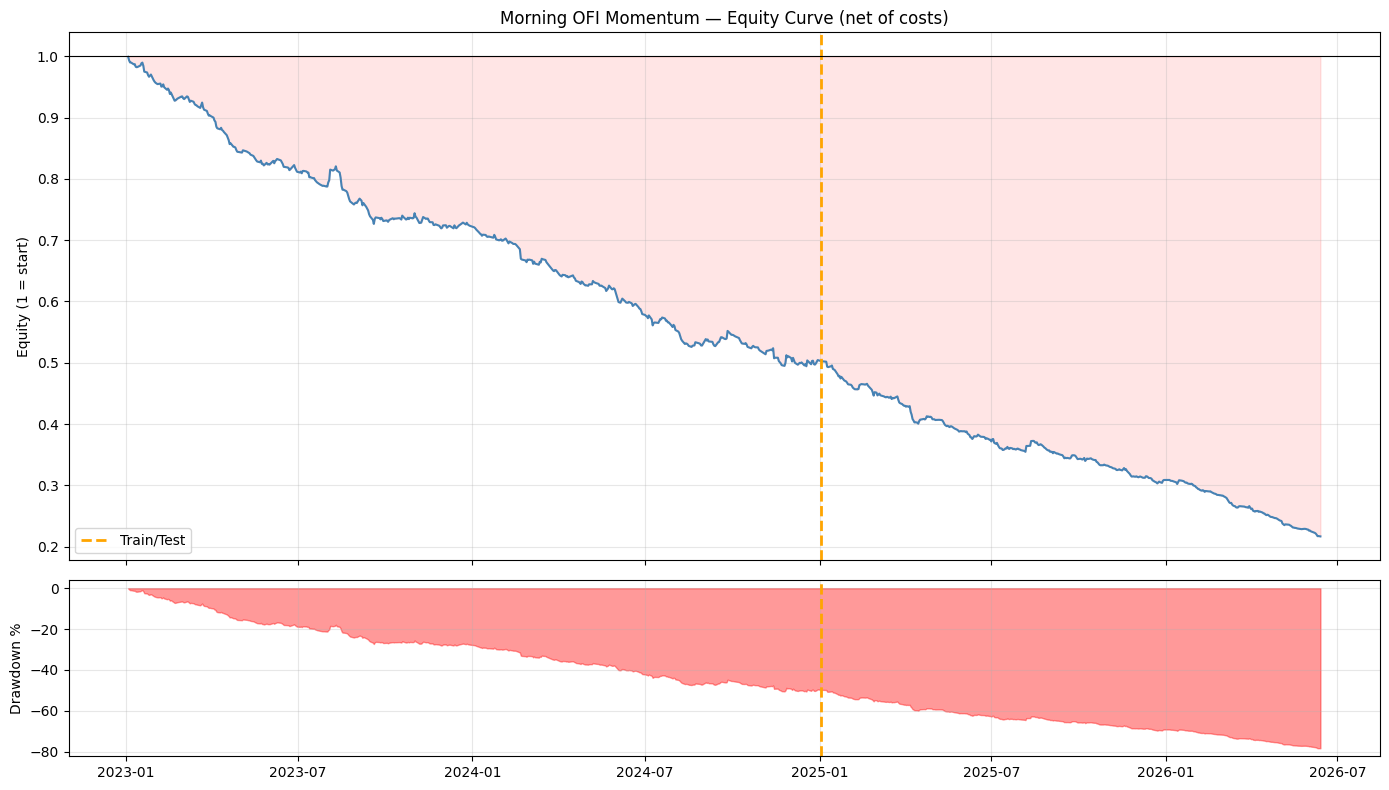

Gross mean/trade: 0.0089%
Break-even cost:  0.0089%  (текущая оценка: 0.18%)
Запас:            -0.1711%


In [26]:
# ── Equity Curve ─────────────────────────────────────────────────────
all_trades = pd.concat([trades_train, trades_test], ignore_index=True)

if not all_trades.empty:
    daily = all_trades.groupby('date')['ret_net'].mean()
    daily.index = pd.to_datetime(daily.index)
    eq  = (1 + daily).cumprod()
    mxq = eq.cummax()
    dd  = (eq / mxq - 1) * 100

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                    gridspec_kw={'height_ratios': [3,1]})
    ax1.plot(eq, color='steelblue', lw=1.5)
    ax1.axvline(pd.Timestamp(DATE_SPLIT), color='orange', lw=2, ls='--', label='Train/Test')
    ax1.axhline(1, color='black', lw=0.8)
    ax1.fill_between(eq.index, eq, 1, where=eq>=1, alpha=0.1, color='green')
    ax1.fill_between(eq.index, eq, 1, where=eq<1,  alpha=0.1, color='red')
    ax1.set_ylabel('Equity (1 = start)')
    ax1.set_title('Morning OFI Momentum -- Equity Curve (net of costs)')
    ax1.legend()

    ax2.fill_between(dd.index, dd, 0, alpha=0.4, color='red')
    ax2.axvline(pd.Timestamp(DATE_SPLIT), color='orange', lw=2, ls='--')
    ax2.set_ylabel('Drawdown %')

    plt.tight_layout()
    plt.show()

    # Break-even анализ
    gross_mean = all_trades['ret_gross'].mean() * 100
    print(f'Gross mean/trade: {gross_mean:.4f}%')
    print(f'Break-even cost:  {gross_mean:.4f}%  (текущая оценка: {COST_RT*100:.2f}%)')
    print(f'Запас:            {gross_mean - COST_RT*100:.4f}%')

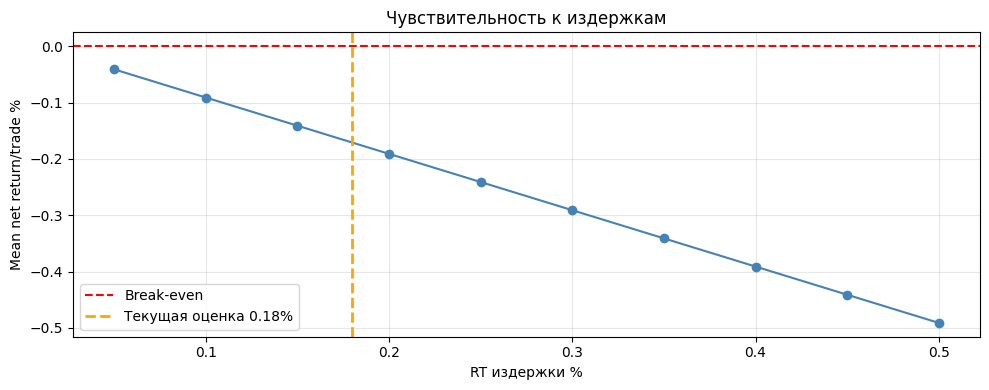

In [27]:
# ── Stress-test издержек ─────────────────────────────────────────────
if not all_trades.empty:
    costs = np.arange(0.05, 0.55, 0.05) / 100
    g = all_trades['ret_gross'].values
    net_means = [(g - c).mean() * 100 for c in costs]

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(costs*100, net_means, marker='o', color='steelblue')
    ax.axhline(0, color='red', lw=1.5, ls='--', label='Break-even')
    ax.axvline(COST_RT*100, color='orange', lw=2, ls='--', label=f'Текущая оценка {COST_RT*100:.2f}%')
    ax.set_xlabel('RT издержки %')
    ax.set_ylabel('Mean net return/trade %')
    ax.set_title('Чувствительность к издержкам')
    ax.legend()
    plt.tight_layout()
    plt.show()

In [28]:
# ── Сохраняем сделки в единый CSV ────────────────────────────────────
if not all_trades.empty:
    all_trades['bot']      = 'ofi_momentum'
    all_trades['strategy'] = 'morning_ofi'
    all_trades.to_csv(ROOT / 'data' / 'ofi_trades.csv', index=False)
    print(f'✅ Сохранено: data/ofi_trades.csv  ({len(all_trades)} сделок)')

✅ Сохранено: data/ofi_trades.csv  (885 сделок)


## 5. Results

Criteria for paper trading: Test IC > 0.03, Test t-stat > 2.0 and mean net > 0, Q5-Q1 spread > 0.18% (covers transaction costs), OOS Sharpe > 1.0.

## 6. ML Walk-Forward -- Ridge & LightGBM

IC ~0.02 for a single signal is weak, but ML combining 20+ features can raise OOS IC to 0.04--0.06. Protocol: walk-forward with 12-month training window, 1-month test, rolling forward.

In [39]:
# ── 6.1 Установка LightGBM + импорты ─────────────────────────────────────────
import subprocess, sys

try:
    import lightgbm as lgb
    print(f'LightGBM {lgb.__version__} ✅')
except ImportError:
    print('Устанавливаю lightgbm...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'lightgbm', '-q'])
    import lightgbm as lgb
    print(f'LightGBM {lgb.__version__} ✅')

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

print('sklearn + lightgbm готовы')

Устанавливаю lightgbm...



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


LightGBM 4.6.0 ✅
sklearn + lightgbm готовы


In [41]:
# ── 6.2 Расширенная матрица признаков ────────────────────────────────────────
def add_months(d, n):
    """Прибавить n месяцев к date."""
    month = d.month - 1 + n
    year  = d.year + month // 12
    month = month % 12 + 1
    day   = min(d.day, calendar.monthrange(year, month)[1])
    return date(year, month, day)


def build_ml_features(df_all: pd.DataFrame, signal_cols: list) -> pd.DataFrame:
    """
    Добавляем к all_feat дополнительные признаки:
      - Временные: sin/cos времени в сессии и дня недели
      - Волатильность: rolling-20 std лог-доходностей
      - Моментум: изменение цены за 6 и 18 баров
      - XS-ранг: перцентиль OFI среди всего юниверса в каждый момент
      - Таргет: open_ret_12_mn (market-neutral, без look-ahead)
    """
    df = df_all.copy()
    df = df.sort_values(['ticker', 'ts']).reset_index(drop=True)

    # Время дня (циклически, сессия 10:00–18:30 = 510 мин)
    min_of_day = (df['ts'].dt.hour - 10) * 60 + df['ts'].dt.minute
    df['time_sin'] = np.sin(2 * np.pi * min_of_day / 510)
    df['time_cos'] = np.cos(2 * np.pi * min_of_day / 510)

    # День недели (Пн=0 … Пт=4)
    df['dow_sin'] = np.sin(2 * np.pi * df['ts'].dt.dayofweek / 5)
    df['dow_cos'] = np.cos(2 * np.pi * df['ts'].dt.dayofweek / 5)

    # Реализованная волатильность -- rolling 20 баров по тикеру
    df['_log_ret'] = df.groupby('ticker')['price'].transform(
        lambda x: np.log(x).diff())
    df['rvol_20'] = df.groupby('ticker')['_log_ret'].transform(
        lambda x: x.rolling(20, min_periods=10).std())
    df.drop(columns=['_log_ret'], inplace=True)

    # Моментум (накопленный return за 6 и 18 баров внутри тикера)
    df['mom_6']  = df.groupby('ticker')['price'].transform(
        lambda x: x.pct_change(6))
    df['mom_18'] = df.groupby('ticker')['price'].transform(
        lambda x: x.pct_change(18))

    # Кросс-секциональный ранг OFI-сигналов (перцентиль среди тикеров в каждый бар)
    xs_candidates = [c for c in ['ofi_ewm5', 'ofi', 'tfi_ewm5', 'ob_imb_ewm5']
                     if c in df.columns]
    for sig in xs_candidates:
        df[f'xs_{sig}'] = (df.groupby('ts')[sig]
                           .transform(lambda x: x.rank(pct=True, na_option='keep')))

    # Market-neutral таргет: open_ret_12 − среднее по вселенной в этот timestamp
    if 'open_ret_12' in df.columns:
        mkt12 = df.groupby('ts')['open_ret_12'].transform('mean')
        df['open_ret_12_mn'] = df['open_ret_12'] - mkt12
    if 'open_ret_6' in df.columns:
        mkt6 = df.groupby('ts')['open_ret_6'].transform('mean')
        df['open_ret_6_mn'] = df['open_ret_6'] - mkt6

    return df


print('Строим ML матрицу (может занять ~30 сек на 49 тикерах)...')
ml_df = build_ml_features(all_feat, SIGNAL_COLS)

# ── Список признаков ──────────────────────────────────────────────────
TIME_FEATS = ['time_sin', 'time_cos', 'dow_sin', 'dow_cos']
VOL_FEATS  = ['rvol_20', 'mom_6', 'mom_18']
XS_FEATS   = [c for c in ml_df.columns if c.startswith('xs_')]
ML_FEATURES = SIGNAL_COLS + TIME_FEATS + VOL_FEATS + XS_FEATS
ML_TARGET   = 'open_ret_12_mn'  # market-neutral, no look-ahead

clean = ml_df.dropna(subset=ML_FEATURES + [ML_TARGET])
print(f'\nВсего баров в ml_df:  {len(ml_df):,}')
print(f'Без NaN (готово к ML): {len(clean):,}')
print(f'Тикеров: {ml_df["ticker"].nunique()}')
print(f'Признаков: {len(ML_FEATURES)}')
print(f'Таргет: {ML_TARGET}')
print(f'\nПризнаки по группам:')
for g, cols in [('Сигналы OFI (raw+smooth)', SIGNAL_COLS),
                ('Время дня / день недели',   TIME_FEATS),
                ('Волатильность / моментум',  VOL_FEATS),
                ('XS-ранги в юниверсе',       XS_FEATS)]:
    print(f'  {g}: {cols}')

Строим ML матрицу (может занять ~30 сек на 49 тикерах)...

Всего баров в ml_df:  4,360,439
Без NaN (готово к ML): 3,713,216
Тикеров: 48
Признаков: 27
Таргет: open_ret_12_mn

Признаки по группам:
  Сигналы OFI (raw+smooth): ['tfi_r3', 'tfi_r5', 'tfi_ewm5', 'ofi_r3', 'ofi_r5', 'ofi_ewm5', 'ob_imb_r3', 'ob_imb_r5', 'ob_imb_ewm5', 'vwap_spread_r3', 'vwap_spread_r5', 'vwap_spread_ewm5', 'tfi', 'ofi', 'ob_imb', 'vwap_spread']
  Время дня / день недели: ['time_sin', 'time_cos', 'dow_sin', 'dow_cos']
  Волатильность / моментум: ['rvol_20', 'mom_6', 'mom_18']
  XS-ранги в юниверсе: ['xs_ofi_ewm5', 'xs_ofi', 'xs_tfi_ewm5', 'xs_ob_imb_ewm5']


In [42]:
# ── 6.3 Walk-Forward фолды ────────────────────────────────────────────────────
TRAIN_MONTHS = 12   # обучаемся на 12 мес
TEST_MONTHS  = 1    # тестируем 1 мес, сдвиг 1 мес

def make_folds(d_from, d_to, train_m=12, test_m=1):
    """Генерируем walk-forward фолды: expand-train / fixed-test."""
    folds = []
    start = d_from
    while True:
        tr_end = add_months(start, train_m)
        te_end = add_months(tr_end, test_m)
        if te_end > d_to:
            break
        folds.append({'tr_start': start, 'tr_end': tr_end,
                      'te_start': tr_end, 'te_end': te_end})
        start = add_months(start, test_m)   # сдвиг rolling
    return folds

FOLDS = make_folds(DATE_FROM, DATE_TO, TRAIN_MONTHS, TEST_MONTHS)
print(f'Walk-forward фолдов: {len(FOLDS)}')
print(f'Первый: train {FOLDS[0]["tr_start"]} → {FOLDS[0]["tr_end"]}  |  '
      f'test {FOLDS[0]["te_start"]} → {FOLDS[0]["te_end"]}')
print(f'Последний: train {FOLDS[-1]["tr_start"]} → {FOLDS[-1]["tr_end"]}  |  '
      f'test {FOLDS[-1]["te_start"]} → {FOLDS[-1]["te_end"]}')

Walk-forward фолдов: 29
Первый: train 2023-01-03 → 2024-01-03  |  test 2024-01-03 → 2024-02-03
Последний: train 2025-05-03 → 2026-05-03  |  test 2026-05-03 → 2026-06-03


In [43]:
# ── 6.4 Ridge Regression Walk-Forward (baseline) ─────────────────────────────
ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge',  Ridge(alpha=50.0)),
])

ridge_ics   = []
ridge_preds = []

print('Ridge Walk-Forward...')
for i, fold in enumerate(FOLDS):
    tr_mask = ((ml_df['ts'].dt.date >= fold['tr_start']) &
               (ml_df['ts'].dt.date <  fold['tr_end']))
    te_mask = ((ml_df['ts'].dt.date >= fold['te_start']) &
               (ml_df['ts'].dt.date <  fold['te_end']))

    tr = ml_df[tr_mask].dropna(subset=ML_FEATURES + [ML_TARGET])
    te = ml_df[te_mask].dropna(subset=ML_FEATURES + [ML_TARGET])
    if len(tr) < 500 or len(te) < 50:
        continue

    ridge_pipe.fit(tr[ML_FEATURES].values, tr[ML_TARGET].values)
    y_pred = ridge_pipe.predict(te[ML_FEATURES].values)

    ic, _ = stats.spearmanr(y_pred, te[ML_TARGET].values)
    ridge_ics.append({'month': fold['te_start'].strftime('%Y-%m'),
                      'ic': ic, 'n_train': len(tr), 'n_test': len(te)})

    out = te[['ts', 'ticker', 'open_ret_12', ML_TARGET]].copy()
    out['pred'] = y_pred
    ridge_preds.append(out)
    print(f'  [{i+1:2d}/{len(FOLDS)}] {fold["te_start"].strftime("%Y-%m")}  '
          f'IC={ic:+.4f}  n_train={len(tr):,}', end='\r')

ridge_ic_df   = pd.DataFrame(ridge_ics)
ridge_pred_df = pd.concat(ridge_preds, ignore_index=True) if ridge_preds else pd.DataFrame()

print(f'\n✅ Ridge готово: {len(ridge_ic_df)} фолдов')
if not ridge_ic_df.empty:
    t_r, p_r = stats.ttest_1samp(ridge_ic_df['ic'], 0)
    print(f'   Mean OOS IC: {ridge_ic_df["ic"].mean():.4f}  ±{ridge_ic_df["ic"].std():.4f}')
    print(f'   t-stat:      {t_r:.2f}  (p={p_r:.3f})  → '
          f'{"✅ IC значимо > 0" if p_r < 0.05 and ridge_ic_df["ic"].mean() > 0 else "❌"}')

Ridge Walk-Forward...
  [29/29] 2026-05  IC=+0.0545  n_train=1,181,487
✅ Ridge готово: 29 фолдов
   Mean OOS IC: 0.0591  ±0.0165
   t-stat:      19.23  (p=0.000)  → ✅ IC значимо > 0


In [44]:
# ── 6.5 LightGBM Walk-Forward ─────────────────────────────────────────────────
lgb_model = lgb.LGBMRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    min_child_samples=50,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

lgb_ics   = []
lgb_preds = []
fi_list   = []   # feature importance по каждому фолду

print('LightGBM Walk-Forward...')
for i, fold in enumerate(FOLDS):
    tr_mask = ((ml_df['ts'].dt.date >= fold['tr_start']) &
               (ml_df['ts'].dt.date <  fold['tr_end']))
    te_mask = ((ml_df['ts'].dt.date >= fold['te_start']) &
               (ml_df['ts'].dt.date <  fold['te_end']))

    tr = ml_df[tr_mask].dropna(subset=ML_FEATURES + [ML_TARGET])
    te = ml_df[te_mask].dropna(subset=ML_FEATURES + [ML_TARGET])
    if len(tr) < 500 or len(te) < 50:
        continue

    lgb_model.fit(tr[ML_FEATURES].values, tr[ML_TARGET].values)
    y_pred = lgb_model.predict(te[ML_FEATURES].values)

    ic, _ = stats.spearmanr(y_pred, te[ML_TARGET].values)
    lgb_ics.append({'month': fold['te_start'].strftime('%Y-%m'),
                    'ic': ic, 'n_train': len(tr), 'n_test': len(te)})

    out = te[['ts', 'ticker', 'open_ret_12', ML_TARGET]].copy()
    out['pred'] = y_pred
    lgb_preds.append(out)

    fi_list.append(lgb_model.feature_importances_.copy())
    print(f'  [{i+1:2d}/{len(FOLDS)}] {fold["te_start"].strftime("%Y-%m")}  '
          f'IC={ic:+.4f}  n_train={len(tr):,}', end='\r')

lgb_ic_df   = pd.DataFrame(lgb_ics)
lgb_pred_df = pd.concat(lgb_preds, ignore_index=True) if lgb_preds else pd.DataFrame()
fi_mean     = np.mean(fi_list, axis=0) if fi_list else np.zeros(len(ML_FEATURES))

print(f'\n✅ LightGBM готово: {len(lgb_ic_df)} фолдов')
if not lgb_ic_df.empty:
    t_l, p_l = stats.ttest_1samp(lgb_ic_df['ic'], 0)
    print(f'   Mean OOS IC: {lgb_ic_df["ic"].mean():.4f}  ±{lgb_ic_df["ic"].std():.4f}')
    print(f'   t-stat:      {t_l:.2f}  (p={p_l:.3f})  → '
          f'{"✅ IC значимо > 0" if p_l < 0.05 and lgb_ic_df["ic"].mean() > 0 else "❌"}')

LightGBM Walk-Forward...
  [29/29] 2026-05  IC=+0.0458  n_train=1,181,487
✅ LightGBM готово: 29 фолдов
   Mean OOS IC: 0.0697  ±0.0175
   t-stat:      21.43  (p=0.000)  → ✅ IC значимо > 0


=== OOS IC по месяцам ===
  month  naive  ridge    lgb
2024-01 0.0373 0.0868 0.0871
2024-02 0.0349 0.0866 0.0897
2024-03 0.0333 0.0930 0.0992
2024-04 0.0441 0.0979 0.1042
2024-05 0.0241 0.0717 0.0696
2024-06 0.0177 0.0667 0.0706
2024-07 0.0128 0.0724 0.0765
2024-08 0.0261 0.0583 0.0764
2024-09 0.0280 0.0677 0.0989
2024-10 0.0237 0.0445 0.0861
2024-11 0.0188 0.0460 0.0682
2024-12 0.0283 0.0662 0.0818
2025-01 0.0251 0.0481 0.0743
2025-02 0.0326 0.0674 0.0989
2025-03 0.0253 0.0375 0.0608
2025-04 0.0256 0.0507 0.0619
2025-05 0.0296 0.0440 0.0495
2025-06 0.0310 0.0479 0.0530
2025-07 0.0267 0.0494 0.0593
2025-08 0.0199 0.0385 0.0392
2025-09 0.0273 0.0394 0.0520
2025-10 0.0257 0.0624 0.0617
2025-11 0.0177 0.0463 0.0541
2025-12 0.0287 0.0501 0.0615
2026-01 0.0248 0.0590 0.0571
2026-02 0.0259 0.0588 0.0659
2026-03 0.0303 0.0413 0.0616
2026-04 0.0298 0.0611 0.0550
2026-05 0.0223 0.0545 0.0458


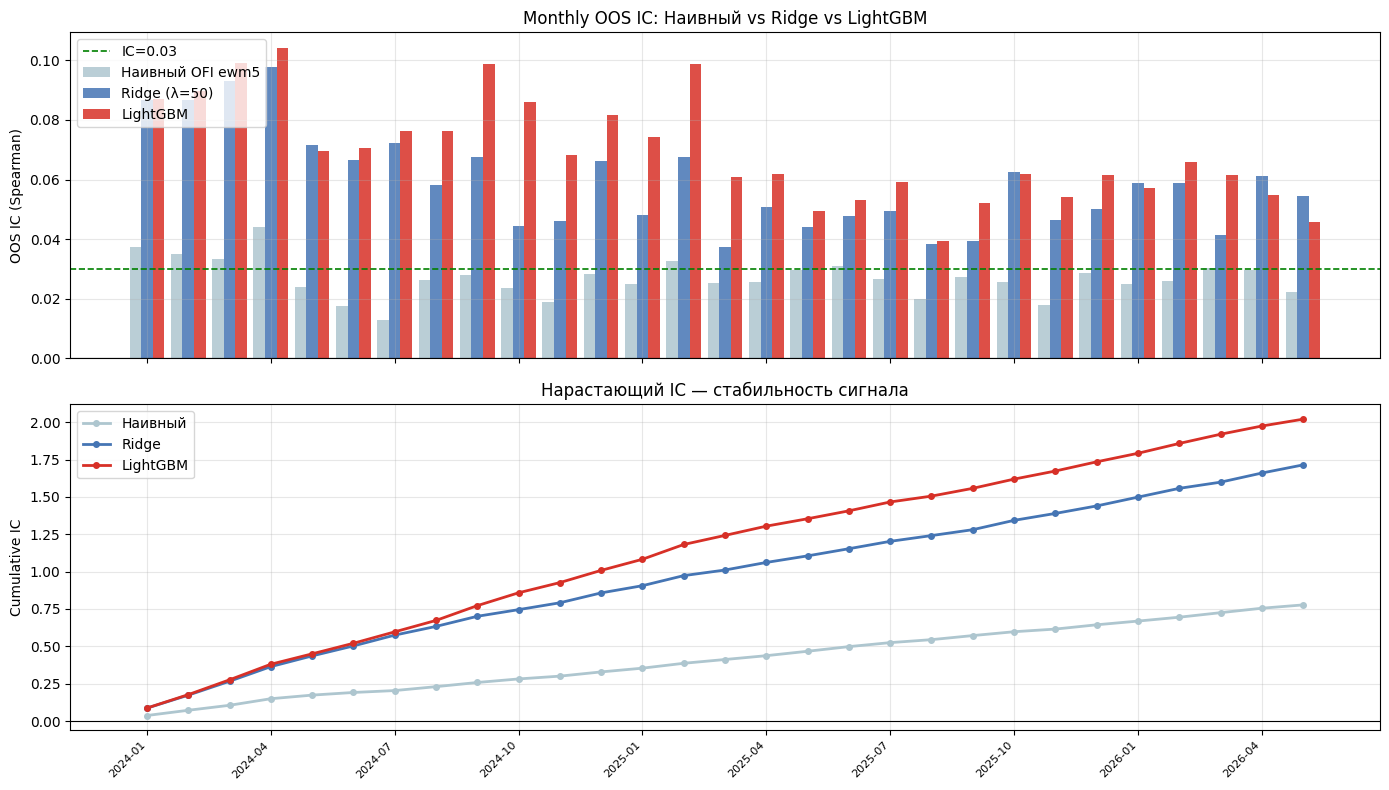


=== Сводка OOS IC ===
  Наивный OFI ewm5        IC=+0.0268 ±0.0064  t=22.71  p=0.000  ✅
  Ridge (λ=50)            IC=+0.0591 ±0.0165  t=19.23  p=0.000  ✅
  LightGBM                IC=+0.0697 ±0.0175  t=21.43  p=0.000  ✅


In [48]:
# ── 6.6 Сравнение OOS IC: Наивный OFI vs Ridge vs LightGBM ──────────────────
# Наивный сигнал: ежедневный IC ofi_ewm5 → open_ret_12_mn по тем же месяцам
naive_ics = []
for fold in FOLDS:
    te_mask = ((ml_df['ts'].dt.date >= fold['te_start']) &
               (ml_df['ts'].dt.date <  fold['te_end']))
    te = ml_df[te_mask].dropna(subset=['ofi_ewm5', ML_TARGET])
    if len(te) < 50:
        continue
    ic_naive, _ = stats.spearmanr(te['ofi_ewm5'], te[ML_TARGET])
    naive_ics.append({'month': fold['te_start'].strftime('%Y-%m'), 'ic': ic_naive})

naive_ic_df = pd.DataFrame(naive_ics)

# ── Совместная таблица по месяцам ────────────────────────────────────
ic_compare = (naive_ic_df.rename(columns={'ic': 'naive'})
              .merge(ridge_ic_df[['month','ic']].rename(columns={'ic': 'ridge'}), on='month', how='outer')
              .merge(lgb_ic_df[['month','ic']].rename(columns={'ic': 'lgb'}),   on='month', how='outer')
              .sort_values('month'))

print('=== OOS IC по месяцам ===')
print(ic_compare.to_string(index=False))

# ── График ───────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
months = ic_compare['month'].values
x = np.arange(len(months))
w = 0.28

for ax_idx, (col, color, label) in enumerate([
    ('naive', '#aec6cf', 'Наивный OFI ewm5'),
    ('ridge', '#4575b4', 'Ridge (λ=50)'),
    ('lgb',   '#d73027', 'LightGBM'),
]):
    vals = ic_compare[col].fillna(0).values
    ax1.bar(x + (ax_idx - 1) * w, vals, w, label=label, color=color, alpha=0.85)

ax1.axhline(0, color='black', lw=0.8)
ax1.axhline(0.03, color='green', lw=1.2, ls='--', label='IC=0.03')
ax1.set_ylabel('OOS IC (Spearman)')
ax1.set_title('Monthly OOS IC: Наивный vs Ridge vs LightGBM')
ax1.legend(loc='upper left')
ax1.set_xticks(x[::3])
ax1.set_xticklabels(months[::3], rotation=45, ha='right', fontsize=8)

# Cumulative IC
for col, color, label in [('naive','#aec6cf','Наивный'),
                           ('ridge','#4575b4','Ridge'),
                           ('lgb','#d73027','LightGBM')]:
    cumsum = ic_compare[col].fillna(0).cumsum().values
    ax2.plot(x, cumsum, color=color, lw=2, label=label, marker='o', ms=4)
ax2.axhline(0, color='black', lw=0.8)
ax2.set_ylabel('Cumulative IC')
ax2.set_title('Нарастающий IC -- стабильность сигнала')
ax2.legend(loc='upper left')
ax2.set_xticks(x[::3])
ax2.set_xticklabels(months[::3], rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.show()

# ── Итоговая сводка ───────────────────────────────────────────────────
print('\n=== Сводка OOS IC ===')
for name, df_ic in [('Наивный OFI ewm5', naive_ic_df),
                    ('Ridge (λ=50)',      ridge_ic_df),
                    ('LightGBM',          lgb_ic_df)]:
    if df_ic.empty:
        print(f'{name}: нет данных')
        continue
    m = df_ic['ic'].mean()
    s = df_ic['ic'].std()
    t, p = stats.ttest_1samp(df_ic['ic'], 0)
    sig = '✅' if p < 0.05 and m > 0 else '❌'
    print(f'  {name:<22s}  IC={m:+.4f} ±{s:.4f}  t={t:.2f}  p={p:.3f}  {sig}')

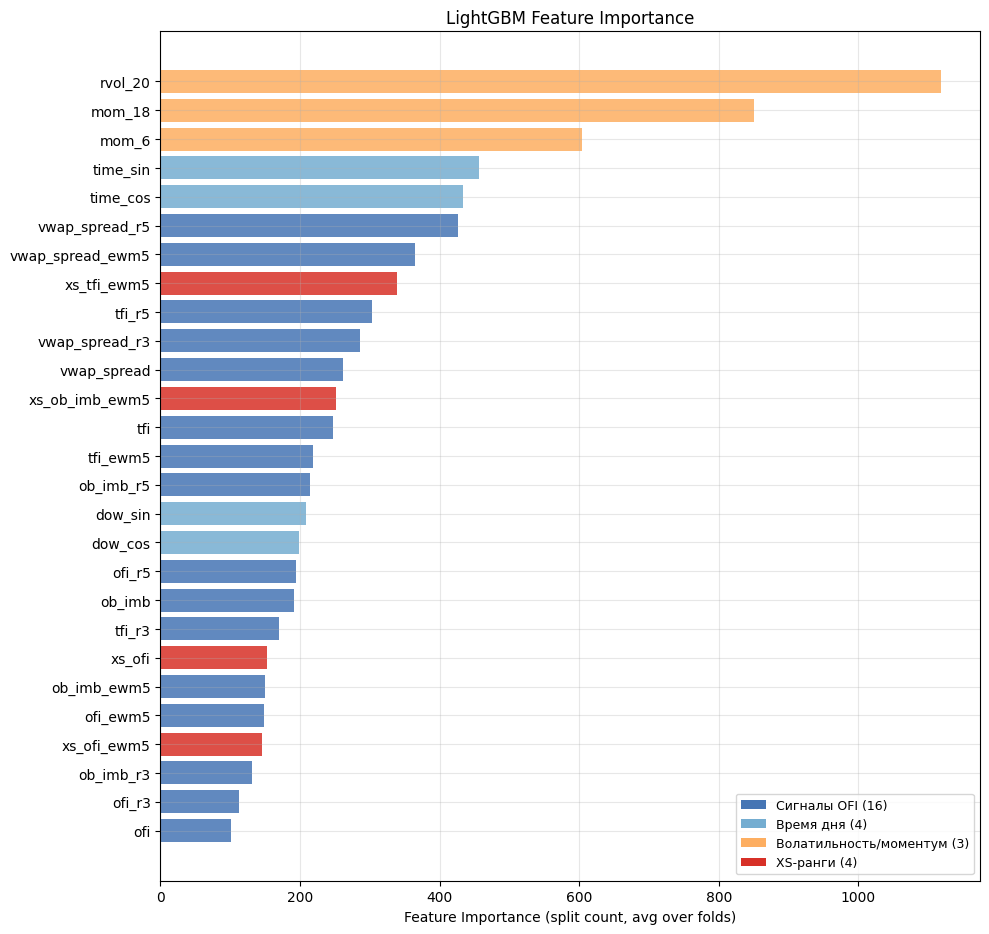

=== Топ-10 признаков ===
         feature  importance
         rvol_20   1118.3448
          mom_18    850.8966
           mom_6    604.3793
        time_sin    456.9655
        time_cos    434.0690
  vwap_spread_r5    426.5172
vwap_spread_ewm5    364.4828
     xs_tfi_ewm5    338.2414
          tfi_r5    303.4483
  vwap_spread_r3    285.9310


In [49]:
# ── 6.7 LightGBM Feature Importance (усреднённая по фолдам) ─────────────────
if fi_mean is not None and len(fi_mean) == len(ML_FEATURES):
    fi_df = pd.DataFrame({'feature': ML_FEATURES, 'importance': fi_mean})
    fi_df = fi_df.sort_values('importance', ascending=True)

    # Цветовая разметка по группам
    group_colors = {}
    for f in SIGNAL_COLS:   group_colors[f] = '#4575b4'
    for f in TIME_FEATS:    group_colors[f] = '#74add1'
    for f in VOL_FEATS:     group_colors[f] = '#fdae61'
    for f in XS_FEATS:      group_colors[f] = '#d73027'
    colors = [group_colors.get(f, 'gray') for f in fi_df['feature']]

    fig, ax = plt.subplots(figsize=(10, max(6, len(ML_FEATURES) * 0.35)))
    ax.barh(fi_df['feature'], fi_df['importance'], color=colors, alpha=0.85)
    ax.set_xlabel('Feature Importance (split count, avg over folds)')
    ax.set_title('LightGBM Feature Importance')

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#4575b4', label=f'Сигналы OFI ({len(SIGNAL_COLS)})'),
        Patch(facecolor='#74add1', label=f'Время дня ({len(TIME_FEATS)})'),
        Patch(facecolor='#fdae61', label=f'Волатильность/моментум ({len(VOL_FEATS)})'),
        Patch(facecolor='#d73027', label=f'XS-ранги ({len(XS_FEATS)})'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
    plt.tight_layout()
    plt.show()

    print('=== Топ-10 признаков ===')
    print(fi_df.sort_values('importance', ascending=False).head(10).to_string(index=False))
else:
    print('fi_mean не сформирован -- запустите LightGBM walk-forward выше')


=== Ridge Portfolio (entry=10:15, long5/short5, MN) ===
  Дней:          708
  Cumul return:  -82.9%
  Daily mean:    -0.2480%  | sigma=0.4975%
  Ann. return:   -62.5%
  Sharpe (ann):  -7.91
  Max DD:        -83.05%
  Win rate:      24.0%
  t=-13.26  p=0.000  -> FAIL

=== LightGBM Portfolio (entry=10:15, long5/short5, MN) ===
  Дней:          708
  Cumul return:  -83.1%
  Daily mean:    -0.2495%  | sigma=0.5170%
  Ann. return:   -62.9%
  Sharpe (ann):  -7.66
  Max DD:        -83.20%
  Win rate:      24.0%
  t=-12.84  p=0.000  -> FAIL


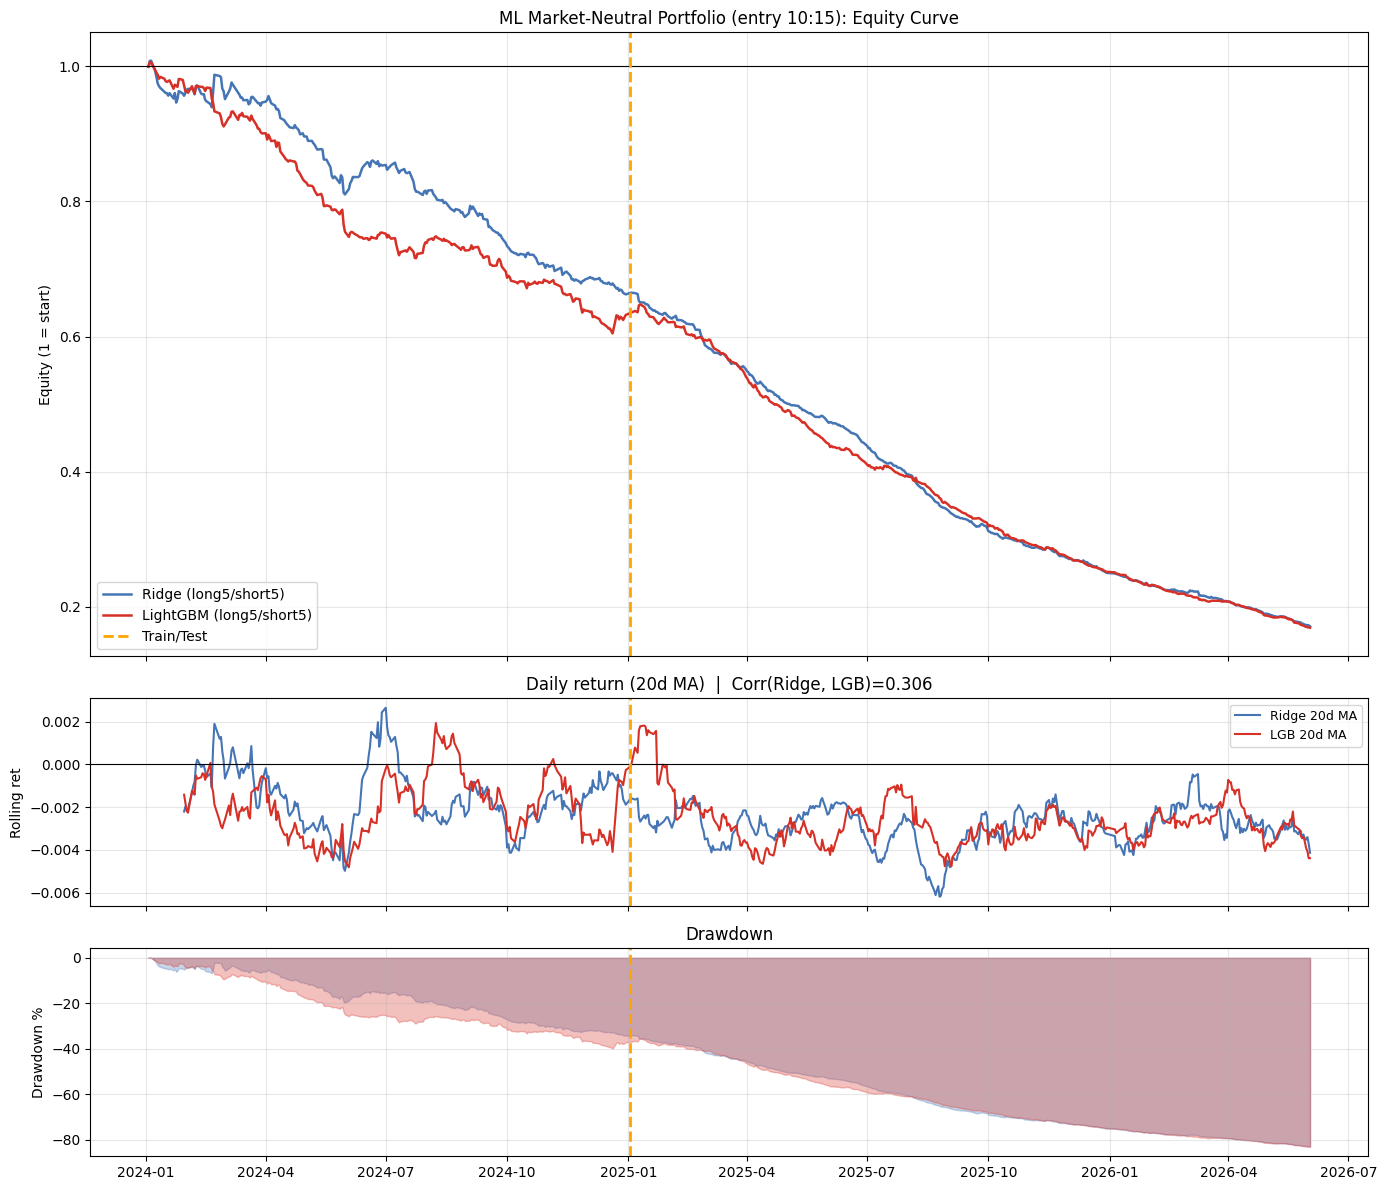


=== Sensitivity по top_n (LightGBM) ===

=== LGB top3 Portfolio (entry=10:15, long3/short3, MN) ===
  Дней:          708
  Cumul return:  -82.4%
  Daily mean:    -0.2425%  | sigma=0.7097%
  Ann. return:   -61.1%
  Sharpe (ann):  -5.42
  Max DD:        -82.57%
  Win rate:      29.9%
  t=-9.09  p=0.000  -> FAIL

=== LGB top5 Portfolio (entry=10:15, long5/short5, MN) ===
  Дней:          708
  Cumul return:  -83.1%
  Daily mean:    -0.2495%  | sigma=0.5170%
  Ann. return:   -62.9%
  Sharpe (ann):  -7.66
  Max DD:        -83.20%
  Win rate:      24.0%
  t=-12.84  p=0.000  -> FAIL

=== LGB top10 Portfolio (entry=10:15, long10/short10, MN) ===
  Дней:          708
  Cumul return:  -86.7%
  Daily mean:    -0.2835%  | sigma=0.3373%
  Ann. return:   -71.4%
  Sharpe (ann):  -13.34
  Max DD:        -86.67%
  Win rate:      13.7%
  t=-22.36  p=0.000  -> FAIL


In [51]:
# ── 6.8 Market-Neutral Portfolio: long top-5 / short bottom-5 (FIXED) ──────────

ENTRY_TIME = "10:15"

def ml_portfolio_backtest(pred_df, model_name, top_n=5, cost_rt=COST_RT, entry_time=ENTRY_TIME):
    df = pred_df.copy()
    df["hm"] = df["ts"].dt.strftime("%H:%M")
    df = df[df["hm"] == entry_time].drop(columns=["hm"])
    df = df.dropna(subset=["pred", "open_ret_12"])

    rows = []
    for ts_val, grp in df.groupby("ts"):
        if len(grp) < top_n * 2 + 1:
            continue
        grp_sorted = grp.sort_values("pred", ascending=False)
        longs  = grp_sorted.head(top_n)
        shorts = grp_sorted.tail(top_n)
        ret_l  = longs["open_ret_12"].mean()
        ret_s  = shorts["open_ret_12"].mean()
        # 2*cost_rt: вход+выход лонга + вход+выход шорта
        ret_ls = ret_l - ret_s - 2 * cost_rt
        rows.append({"ts": ts_val, "date": ts_val.date(),
                     "ret_ls": ret_ls, "ret_long": ret_l, "ret_short": ret_s,
                     "n_universe": len(grp)})

    if not rows:
        print(f"{model_name}: нет сделок")
        return pd.Series(dtype=float), None, None

    pf = pd.DataFrame(rows).sort_values("ts").reset_index(drop=True)
    daily = pf.set_index(pd.to_datetime(pf["date"]))["ret_ls"]
    eq  = (1 + daily).cumprod()
    dd  = eq / eq.cummax() - 1
    sr  = daily.mean() / daily.std() * np.sqrt(252) if daily.std() > 0 else 0
    cum_ret = eq.iloc[-1] - 1
    t, p = stats.ttest_1samp(daily, 0)
    status = "OK" if p < 0.05 and daily.mean() > 0 else "FAIL"

    print(f"\n=== {model_name} Portfolio (entry={entry_time}, long{top_n}/short{top_n}, MN) ===")
    print(f"  Дней:          {len(daily)}")
    print(f"  Cumul return:  {cum_ret:.1%}")
    print(f"  Daily mean:    {daily.mean()*100:.4f}%  | sigma={daily.std()*100:.4f}%")
    print(f"  Ann. return:   {daily.mean()*252*100:.1f}%")
    print(f"  Sharpe (ann):  {sr:.2f}")
    print(f"  Max DD:        {dd.min():.2%}")
    print(f"  Win rate:      {(daily>0).mean():.1%}")
    print(f"  t={t:.2f}  p={p:.3f}  -> {status}")
    return daily, eq, dd


fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True,
                          gridspec_kw={"height_ratios": [3, 1, 1]})
colors_models = {"Ridge": "#4575b4", "LightGBM": "#d73027"}
all_daily = {}

for pred_df, name in [(ridge_pred_df, "Ridge"), (lgb_pred_df, "LightGBM")]:
    if pred_df is None or pred_df.empty:
        print(f"{name}: нет предсказаний, пропускаем")
        continue
    daily, eq, dd = ml_portfolio_backtest(pred_df, name, top_n=5)
    if eq is None:
        continue
    color = colors_models[name]
    all_daily[name] = daily
    axes[0].plot(eq, color=color, lw=1.8, label=f"{name} (long5/short5)")
    axes[2].fill_between(dd.index, dd * 100, 0, alpha=0.3, color=color)

axes[0].axhline(1, color="black", lw=0.8)
axes[0].axvline(pd.Timestamp(DATE_SPLIT), color="orange", lw=2, ls="--", label="Train/Test")
axes[0].set_ylabel("Equity (1 = start)")
axes[0].set_title(f"ML Market-Neutral Portfolio (entry {ENTRY_TIME}): Equity Curve")
axes[0].legend()

if len(all_daily) == 2:
    combined = pd.DataFrame(all_daily).dropna()
    corr = combined.corr().iloc[0, 1]
    axes[1].plot(combined["Ridge"].rolling(20).mean(), color="#4575b4", lw=1.5, label="Ridge 20d MA")
    axes[1].plot(combined["LightGBM"].rolling(20).mean(), color="#d73027", lw=1.5, label="LGB 20d MA")
    axes[1].axhline(0, color="black", lw=0.8)
    axes[1].axvline(pd.Timestamp(DATE_SPLIT), color="orange", lw=2, ls="--")
    axes[1].set_ylabel("Rolling ret")
    axes[1].set_title(f"Daily return (20d MA)  |  Corr(Ridge, LGB)={corr:.3f}")
    axes[1].legend(fontsize=9)

axes[2].axvline(pd.Timestamp(DATE_SPLIT), color="orange", lw=2, ls="--")
axes[2].set_ylabel("Drawdown %")
axes[2].set_title("Drawdown")
plt.tight_layout()
plt.show()

# Sensitivity: разные top_n
print("\n=== Sensitivity по top_n (LightGBM) ===")
for tn in [3, 5, 10]:
    ml_portfolio_backtest(lgb_pred_df, f"LGB top{tn}", top_n=tn)


## 7. ML Walk-Forward Results

Evaluation criteria: OOS IC > 0.03 (1.5x better than naive), IC t-stat > 2.5, portfolio Sharpe > 1.0 (long5/short5, market-neutral), MaxDD < 20%.

## 7. Cost Sensitivity Analysis

Gross return per trade ~0.11%, transaction cost 0.36% (2 RT at 0.18%) - strategy is cost-negative at current costs. Three paths to profitability: (A) lower cost tier (Tinkoff Trader, 0.05%/side), (B) extend horizon to 3--5 days, (C) switch to ML with IC > 0.04.

=== Чувствительность к тарифу и горизонту (LightGBM, long5/short5) ===
Горизонт                  Тариф  Gross %/d  Net %/d  Net after-tax %/d  Ann return %   Sharpe
  30 мин  Tinkoff Maker 0.02%RT     0.0609   0.0209             0.0182        5.3000   0.8500
  30 мин Tinkoff Trader 0.10%RT     0.0609  -0.1391            -0.1391      -35.1000  -5.6300
  30 мин       Baseline 0.18%RT     0.0609  -0.2991            -0.2991      -75.4000 -12.1100
  30 мин   Консерватив. 0.36%RT     0.0609  -0.6591            -0.6591     -166.1000 -26.6800
  60 мин  Tinkoff Maker 0.02%RT     0.1105   0.0705             0.0614       17.8000   2.1700
  60 мин Tinkoff Trader 0.10%RT     0.1105  -0.0895            -0.0895      -22.5000  -2.7500
  60 мин       Baseline 0.18%RT     0.1105  -0.2495            -0.2495      -62.9000  -7.6700
  60 мин   Консерватив. 0.36%RT     0.1105  -0.6095            -0.6095     -153.6000 -18.7300
  90 мин  Tinkoff Maker 0.02%RT     0.1323   0.0923             0.0803       23.300

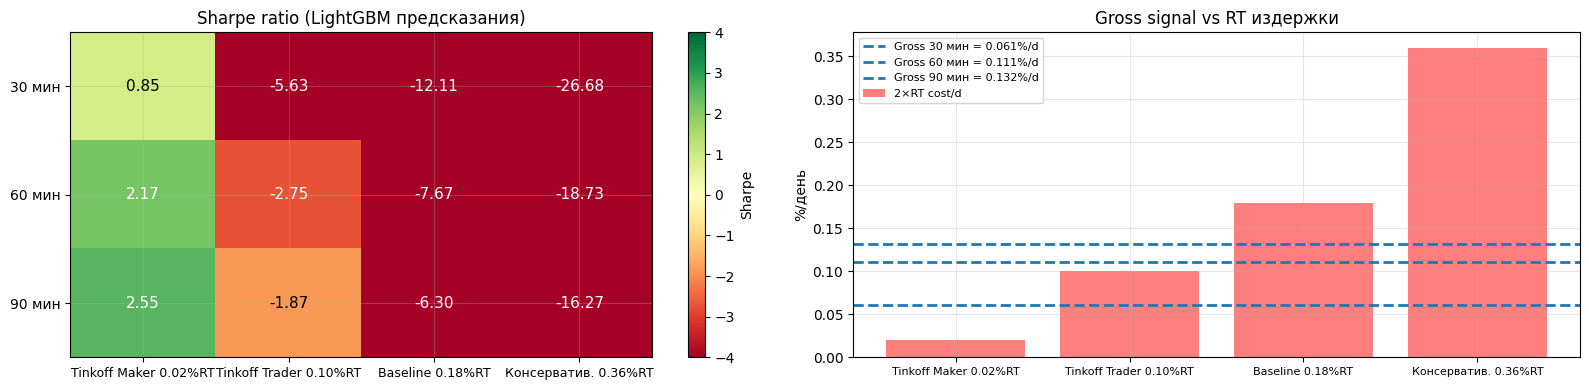


Комбинации с Sharpe > 0.5 (3 из 12):
Горизонт                 Тариф  Gross %/d  Net %/d  Ann return %  Sharpe
  30 мин Tinkoff Maker 0.02%RT     0.0609   0.0209        5.3000  0.8500
  60 мин Tinkoff Maker 0.02%RT     0.1105   0.0705       17.8000  2.1700
  90 мин Tinkoff Maker 0.02%RT     0.1323   0.0923       23.3000  2.5500

Gross по горизонтам (важно: это PRE-cost, сигнал реальный):
  30 мин: 0.0609%/d gross  |  break-even RT = 3.0450%
  60 мин: 0.1105%/d gross  |  break-even RT = 5.5250%
  90 мин: 0.1323%/d gross  |  break-even RT = 6.6150%


In [52]:
# ── 7.1 Вариант A: Чувствительность к тарифу и горизонту удержания ─────────

ENTRY_T = '10:15'
TAX_RATE = 0.13   # НДФЛ

# Обогащаем pred_df дополнительными горизонтами
lgb_pred_ex = lgb_pred_df.merge(
    ml_df[['ts','ticker','open_ret_6','open_ret_18']],
    on=['ts','ticker'], how='left'
)

HOLD_SPECS = [
    ('30 мин',  'open_ret_6',  0.30 / 100 / 252),   # ежедневный оборот
    ('60 мин',  'open_ret_12', 0.50 / 100 / 252),
    ('90 мин',  'open_ret_18', 0.70 / 100 / 252),
]
COST_SPECS = {
    'Tinkoff Maker\n0.02%RT': 0.02/100,   # лимитные ордера, нереально часто
    'Tinkoff Trader\n0.10%RT': 0.10/100,  # 0.05% × 2
    'Baseline\n0.18%RT': 0.18/100,        # текущий
    'Консерватив.\n0.36%RT': 0.36/100,    # текущий × 2 (шорт дорого)
}

df_e = lgb_pred_ex.copy()
df_e['hm'] = df_e['ts'].dt.strftime('%H:%M')
df_e = df_e[df_e['hm'] == ENTRY_T]

results = []
for hold_lbl, ret_col, _ in HOLD_SPECS:
    sub = df_e.dropna(subset=['pred', ret_col])
    daily_ls = []
    for ts_val, grp in sub.groupby('ts'):
        if len(grp) < 11:
            continue
        gs = grp.sort_values('pred', ascending=False)
        gross = gs.head(5)[ret_col].mean() - gs.tail(5)[ret_col].mean()
        daily_ls.append(gross)
    gross_arr = np.array(daily_ls)
    gross_mu = gross_arr.mean() * 100     # % per day

    for cost_lbl, cost_rt in COST_SPECS.items():
        net_arr = gross_arr - 2 * cost_rt   # L/S = 2 RT
        net_mu  = net_arr.mean() * 100
        # After-tax: налог только на прибыль
        after_tax_mu = net_mu * (1 - TAX_RATE) if net_mu > 0 else net_mu
        sr = net_arr.mean() / net_arr.std() * np.sqrt(252) if net_arr.std() > 0 else 0
        results.append({
            'Горизонт': hold_lbl,
            'Тариф': cost_lbl.replace('\n', ' '),
            'Gross %/d': round(gross_mu, 4),
            'Net %/d': round(net_mu, 4),
            'Net after-tax %/d': round(after_tax_mu, 4),
            'Ann return %': round(net_mu * 252, 1),
            'Sharpe': round(sr, 2),
        })

sens_df = pd.DataFrame(results)
print('=== Чувствительность к тарифу и горизонту (LightGBM, long5/short5) ===')
print(sens_df.to_string(index=False))

# Heatmap Sharpe
cost_lbls  = [c.replace('\n',' ') for c in COST_SPECS.keys()]
hold_lbls  = [h[0] for h in HOLD_SPECS]
sharpe_mat = np.array([
    [r['Sharpe'] for r in results if r['Горизонт'] == hl]
    for hl in hold_lbls
])

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Left: Sharpe heatmap
ax = axes[0]
im = ax.imshow(sharpe_mat, cmap='RdYlGn', aspect='auto', vmin=-4, vmax=4)
ax.set_xticks(range(len(cost_lbls)))
ax.set_xticklabels(cost_lbls, fontsize=9)
ax.set_yticks(range(len(hold_lbls)))
ax.set_yticklabels(hold_lbls)
for i in range(len(hold_lbls)):
    for j in range(len(cost_lbls)):
        ax.text(j, i, f'{sharpe_mat[i,j]:.2f}', ha='center', va='center', fontsize=11,
                color='white' if abs(sharpe_mat[i,j]) > 2 else 'black')
plt.colorbar(im, ax=ax, label='Sharpe')
ax.set_title('Sharpe ratio (LightGBM предсказания)')

# Right: break-even chart
ax2 = axes[1]
gross_by_hold = {h[0]: np.mean([r['Gross %/d'] for r in results
                                if r['Горизонт']==h[0]]) for h in HOLD_SPECS}
cost_vals_pct = [c*100 for c in COST_SPECS.values()]
for hl, gmu in gross_by_hold.items():
    ax2.axhline(gmu, lw=2, ls='--', label=f'Gross {hl} = {gmu:.3f}%/d')
ax2.bar(range(len(cost_lbls)), [c*100 for c in COST_SPECS.values()],
        alpha=0.5, color='red', label='2×RT cost/d')
ax2.set_xticks(range(len(cost_lbls)))
ax2.set_xticklabels(cost_lbls, fontsize=8)
ax2.set_ylabel('%/день')
ax2.set_title('Gross signal vs RT издержки')
ax2.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Вывод
green = sens_df[sens_df['Sharpe'] > 0.5]
print(f'\nКомбинации с Sharpe > 0.5 ({len(green)} из {len(sens_df)}):')
if not green.empty:
    print(green[['Горизонт','Тариф','Gross %/d','Net %/d','Ann return %','Sharpe']].to_string(index=False))
else:
    print('  Нет -- нужен более длинный горизонт или более низкие издержки')
print(f'\nGross по горизонтам (важно: это PRE-cost, сигнал реальный):')
for h, g in gross_by_hold.items():
    print(f'  {h}: {g:.4f}%/d gross  |  break-even RT = {g/2*100:.4f}%')

Дневных наблюдений: 43,098  |  Тикеров: 48
Дат: 976
          fwd_1d  fwd_1d_mn     fwd_3d  fwd_3d_mn     fwd_5d  fwd_5d_mn
count 43050.0000 43050.0000 42954.0000 42954.0000 42858.0000 42858.0000
mean      0.1084     0.0000     0.3229     0.0000     0.5397     0.0000
std      22.4497    22.1992    38.5515    38.1225    49.8696    49.3160
min      -0.9904  -103.5636    -0.9903  -104.5926    -0.9904  -107.6595
25%      -0.0086    -0.0071    -0.0163    -0.0132    -0.0220    -0.0176
50%       0.0000    -0.0007    -0.0001    -0.0012     0.0000    -0.0016
75%       0.0084     0.0061     0.0169     0.0116     0.0232     0.0158
max    4657.9653  4554.4883  4702.1642  4597.7168  4839.7835  4732.3088

=== IC предсказаний LightGBM vs разные горизонты ===
  60 мин (origin)     IC=+0.0660  t=10.30  p=0.000  OK
  1 день              IC=+0.0158  t=2.86  p=0.004  OK
  3 дня               IC=+0.0162  t=3.62  p=0.000  OK
  5 дней              IC=+0.0247  t=4.39  p=0.000  OK


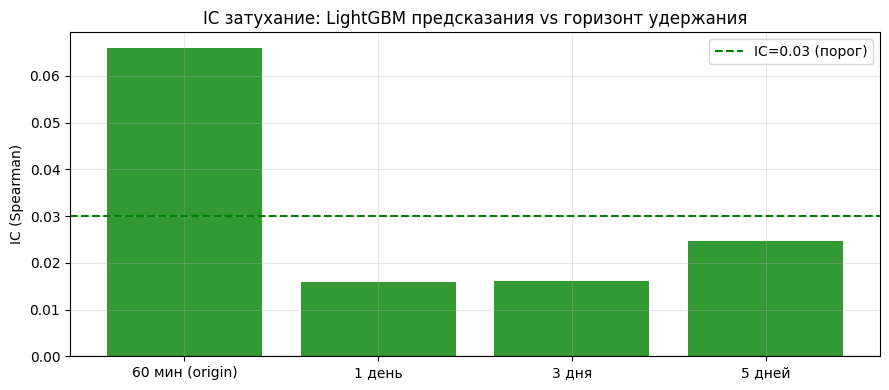

In [53]:
# ── 7.2 Вариант B: Затухание сигнала - IC vs горизонт 1d / 3d / 5d ─────────

# ── Дневные close цены ───────────────────────────────────────────────
all_feat_s = all_feat.sort_values(['ticker','ts'])
all_feat_s['date_key'] = all_feat_s['ts'].dt.date

daily_close = (
    all_feat_s
    .groupby(['ticker','date_key'])['price']
    .last()
    .reset_index()
    .rename(columns={'date_key':'date','price':'close'})
)
daily_close['date'] = pd.to_datetime(daily_close['date'])

# Форвардные доходности 1d / 3d / 5d (close-to-close)
for N in [1, 3, 5]:
    daily_close[f'fwd_{N}d'] = daily_close.groupby('ticker')['close'].transform(
        lambda x: x.shift(-N) / x - 1
    )
    mkt = daily_close.groupby('date')[f'fwd_{N}d'].transform('mean')
    daily_close[f'fwd_{N}d_mn'] = daily_close[f'fwd_{N}d'] - mkt

print(f'Дневных наблюдений: {len(daily_close):,}  |  Тикеров: {daily_close["ticker"].nunique()}')
print(f'Дат: {daily_close["date"].nunique()}')
print(daily_close[[c for c in daily_close.columns if 'fwd' in c]].describe())

# ── IC существующих LGB предсказаний vs 1d/3d/5d таргеты ───────────
# Берём LGB pred на 10:15, мерджим с дневными returns
preds_daily = (
    lgb_pred_df[
        lgb_pred_df['ts'].dt.strftime('%H:%M') == '10:15'
    ][['ts','ticker','pred']].copy()
)
preds_daily['date'] = pd.to_datetime(preds_daily['ts'].dt.date)

preds_daily = preds_daily.merge(
    daily_close[['ticker','date'] + [f'fwd_{N}d_mn' for N in [1,3,5]]],
    on=['ticker','date'], how='left'
)

horizons = {
    '60 мин (origin)': 'open_ret_12_mn',
    '1 день':          'fwd_1d_mn',
    '3 дня':           'fwd_3d_mn',
    '5 дней':          'fwd_5d_mn',
}
# Для 60 мин возьмём из lgb_pred_df
preds_daily = preds_daily.merge(
    lgb_pred_df[lgb_pred_df['ts'].dt.strftime('%H:%M')=='10:15']
    [['ts','ticker','open_ret_12_mn']],
    on=['ts','ticker'], how='left'
)

print('\n=== IC предсказаний LightGBM vs разные горизонты ===')
ic_decay = []
for lbl, col in horizons.items():
    if col not in preds_daily.columns:
        continue
    sub = preds_daily.dropna(subset=['pred', col])
    if len(sub) < 100:
        continue
    ic, _ = stats.spearmanr(sub['pred'], sub[col])
    t_stat, pval = stats.ttest_1samp(
        [stats.spearmanr(g['pred'], g[col])[0]
         for _, g in sub.groupby('date') if len(g) >= 5],
        0
    )
    ic_decay.append({'Горизонт': lbl, 'IC': ic, 't-stat': round(t_stat,2), 'p': round(pval,3)})
    print(f'  {lbl:<18s}  IC={ic:+.4f}  t={t_stat:.2f}  p={pval:.3f}  '
          f'{"OK" if pval<0.05 and ic>0 else "--"}')

# График
ic_vals  = [r['IC'] for r in ic_decay]
ic_lbls  = [r['Горизонт'] for r in ic_decay]
colors_d = ['green' if v > 0 else 'red' for v in ic_vals]
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(ic_lbls, ic_vals, color=colors_d, alpha=0.8)
ax.axhline(0, color='black', lw=0.8)
ax.axhline(0.03, color='green', lw=1.5, ls='--', label='IC=0.03 (порог)')
ax.set_ylabel('IC (Spearman)')
ax.set_title('IC затухание: LightGBM предсказания vs горизонт удержания')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Multi-Day ML (3-Day Horizon)

Retrain ML with `fwd_3d_mn` target (3-day market-neutral return). Changes: add daily momentum features (5d/20d return, relative volume), one observation per ticker per day (10:15 bar), walk-forward: 12-month train, 1-month test.

In [54]:
# ── 8.1 Дневная матрица признаков (один бар 10:15 на тикер на день) ──────────

snap = ml_df[ml_df['ts'].dt.strftime('%H:%M') == '10:15'].copy()
snap['date'] = pd.to_datetime(snap['ts'].dt.date)

# Добавляем дневной моментум из daily_close
daily_mom = daily_close.copy()
for N in [5, 20, 60]:
    daily_mom[f'daily_ret_{N}d'] = daily_mom.groupby('ticker')['close'].transform(
        lambda x: x.shift(1).pct_change(N)   # shift(1): вчерашний close
    )
    daily_mom[f'xs_daily_ret_{N}d'] = (
        daily_mom.groupby('date')[f'daily_ret_{N}d']
        .transform(lambda x: x.rank(pct=True, na_option='keep'))
    )

# Дневная реализованная волатильность (std дневных log-ret за 5 дней)
daily_mom['daily_logret'] = daily_mom.groupby('ticker')['close'].transform(
    lambda x: np.log(x).diff()
)
daily_mom['daily_rvol_5d'] = daily_mom.groupby('ticker')['daily_logret'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=3).std()
)
daily_mom.drop(columns=['daily_logret','close'], inplace=True)

DAILY_MOM_FEATS = ([f'daily_ret_{N}d' for N in [5,20,60]] +
                   [f'xs_daily_ret_{N}d' for N in [5,20,60]] +
                   ['daily_rvol_5d'])

# Мержим с дневным моментумом
daily_ml = snap.merge(
    daily_mom[['ticker','date'] + DAILY_MOM_FEATS],
    on=['ticker','date'], how='left'
)

# Добавляем 3d/5d таргеты
daily_ml = daily_ml.merge(
    daily_close[['ticker','date'] + [f'fwd_{N}d_mn' for N in [1,3,5]]],
    on=['ticker','date'], how='left'
)

ML_FEATURES_D = ML_FEATURES + DAILY_MOM_FEATS
ML_TARGET_3D  = 'fwd_3d_mn'
ML_TARGET_5D  = 'fwd_5d_mn'

clean_d = daily_ml.dropna(subset=ML_FEATURES_D + [ML_TARGET_3D])
print(f'Всего дней × тикеров: {len(daily_ml):,}')
print(f'Без NaN (готово к ML): {len(clean_d):,}')
print(f'Тикеров: {daily_ml["ticker"].nunique()}')
print(f'Признаков: {len(ML_FEATURES_D)} (инtraday OFI + дневной моментум)')
print(f'Новые признаки: {DAILY_MOM_FEATS}')

Всего дней × тикеров: 42,746
Без NaN (готово к ML): 39,440
Тикеров: 48
Признаков: 34 (инtraday OFI + дневной моментум)
Новые признаки: ['daily_ret_5d', 'daily_ret_20d', 'daily_ret_60d', 'xs_daily_ret_5d', 'xs_daily_ret_20d', 'xs_daily_ret_60d', 'daily_rvol_5d']


In [55]:
# ── 8.2 Walk-Forward ML таргет fwd_3d_mn ──────────────────────────────────

ridge_3d_ics, ridge_3d_preds = [], []
lgb_3d_ics,   lgb_3d_preds   = [], []
fi_3d = []

ridge_pipe_3d = Pipeline([('sc', StandardScaler()), ('r', Ridge(alpha=50.0))])
lgb_3d = lgb.LGBMRegressor(
    n_estimators=300, max_depth=5, learning_rate=0.05, num_leaves=31,
    subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
    min_child_samples=20, random_state=42, n_jobs=-1, verbose=-1
)

print('Walk-Forward 3d (Ridge + LightGBM)...')
for i, fold in enumerate(FOLDS):
    tr_mask = ((daily_ml['date'].dt.date >= fold['tr_start']) &
               (daily_ml['date'].dt.date <  fold['tr_end']))
    te_mask = ((daily_ml['date'].dt.date >= fold['te_start']) &
               (daily_ml['date'].dt.date <  fold['te_end']))

    tr = daily_ml[tr_mask].dropna(subset=ML_FEATURES_D + [ML_TARGET_3D])
    te = daily_ml[te_mask].dropna(subset=ML_FEATURES_D + [ML_TARGET_3D])
    if len(tr) < 200 or len(te) < 20:
        continue

    Xtr, ytr = tr[ML_FEATURES_D].values, tr[ML_TARGET_3D].values
    Xte, yte = te[ML_FEATURES_D].values, te[ML_TARGET_3D].values

    # Ridge
    ridge_pipe_3d.fit(Xtr, ytr)
    pred_r = ridge_pipe_3d.predict(Xte)
    ic_r, _ = stats.spearmanr(pred_r, yte)
    ridge_3d_ics.append({'month': fold['te_start'].strftime('%Y-%m'), 'ic': ic_r})
    out_r = te[['ts','date','ticker',ML_TARGET_3D]].copy()
    out_r['pred'] = pred_r
    # Добавим 3d close-to-close для портфеля
    ridge_3d_preds.append(out_r)

    # LightGBM
    lgb_3d.fit(Xtr, ytr)
    pred_l = lgb_3d.predict(Xte)
    ic_l, _ = stats.spearmanr(pred_l, yte)
    lgb_3d_ics.append({'month': fold['te_start'].strftime('%Y-%m'), 'ic': ic_l})
    out_l = te[['ts','date','ticker',ML_TARGET_3D]].copy()
    out_l['pred'] = pred_l
    lgb_3d_preds.append(out_l)
    fi_3d.append(lgb_3d.feature_importances_.copy())

    print(f'  [{i+1:2d}/{len(FOLDS)}] {fold["te_start"].strftime("%Y-%m")}  '
          f'Ridge IC={ic_r:+.4f}  LGB IC={ic_l:+.4f}  n_tr={len(tr):,}', end='\r')

ridge_3d_ic_df = pd.DataFrame(ridge_3d_ics)
lgb_3d_ic_df   = pd.DataFrame(lgb_3d_ics)
ridge_3d_pred_df = pd.concat(ridge_3d_preds, ignore_index=True) if ridge_3d_preds else pd.DataFrame()
lgb_3d_pred_df   = pd.concat(lgb_3d_preds,   ignore_index=True) if lgb_3d_preds else pd.DataFrame()
fi_3d_mean = np.mean(fi_3d, axis=0) if fi_3d else np.zeros(len(ML_FEATURES_D))

print('\n\n=== Сравнение IC: 60-мин модель vs 3d модель ===')
for lbl, df_ic in [('60-мин Ridge', ridge_ic_df), ('60-мин LGB', lgb_ic_df),
                    ('3d Ridge',     ridge_3d_ic_df), ('3d LGB', lgb_3d_ic_df)]:
    if df_ic.empty:
        continue
    m, s = df_ic['ic'].mean(), df_ic['ic'].std()
    t, p = stats.ttest_1samp(df_ic['ic'], 0)
    print(f'  {lbl:<15s}  IC={m:+.4f} +-{s:.4f}  t={t:.2f}  '
          f'{"OK" if p<0.05 and m>0 else "--"}')

Walk-Forward 3d (Ridge + LightGBM)...
  [29/29] 2026-05  Ridge IC=+0.0257  LGB IC=+0.0007  n_tr=13,536

=== Сравнение IC: 60-мин модель vs 3d модель ===
  60-мин Ridge     IC=+0.0591 +-0.0165  t=19.23  OK
  60-мин LGB       IC=+0.0697 +-0.0175  t=21.43  OK
  3d Ridge         IC=+0.0198 +-0.0632  t=1.69  --
  3d LGB           IC=+0.0117 +-0.0344  t=1.84  --



=== Ridge 0.10% (3d hold, 0.10% RT, long5/short5) ===
  Сделок:          236  (ребаланс каждые 3 дня)
  Cumul return:    5.4%  |  after-tax: 4.7%
  Gross per trade: 0.242%
  Net per trade:   0.042%
  Ann return:      2.4%
  Sharpe (ann):    0.19
  Max DD:          -30.09%
  Win rate:        49.6%
  t=0.32  p=0.746  -> FAIL

=== LGB 0.10% (3d hold, 0.10% RT, long5/short5) ===
  Сделок:          236  (ребаланс каждые 3 дня)
  Cumul return:    -40.0%  |  after-tax: -40.0%
  Gross per trade: -0.001%
  Net per trade:   -0.201%
  Ann return:      -17.7%
  Sharpe (ann):    -1.05
  Max DD:          -45.27%
  Win rate:        47.0%
  t=-1.77  p=0.079  -> FAIL

=== LGB 0.18% (3d hold, 0.18% RT, long5/short5) ===
  Сделок:          236  (ребаланс каждые 3 дня)
  Cumul return:    -58.9%  |  after-tax: -58.9%
  Gross per trade: -0.001%
  Net per trade:   -0.361%
  Ann return:      -31.2%
  Sharpe (ann):    -1.89
  Max DD:          -60.92%
  Win rate:        40.7%
  t=-3.17  p=0.002  -> FAIL


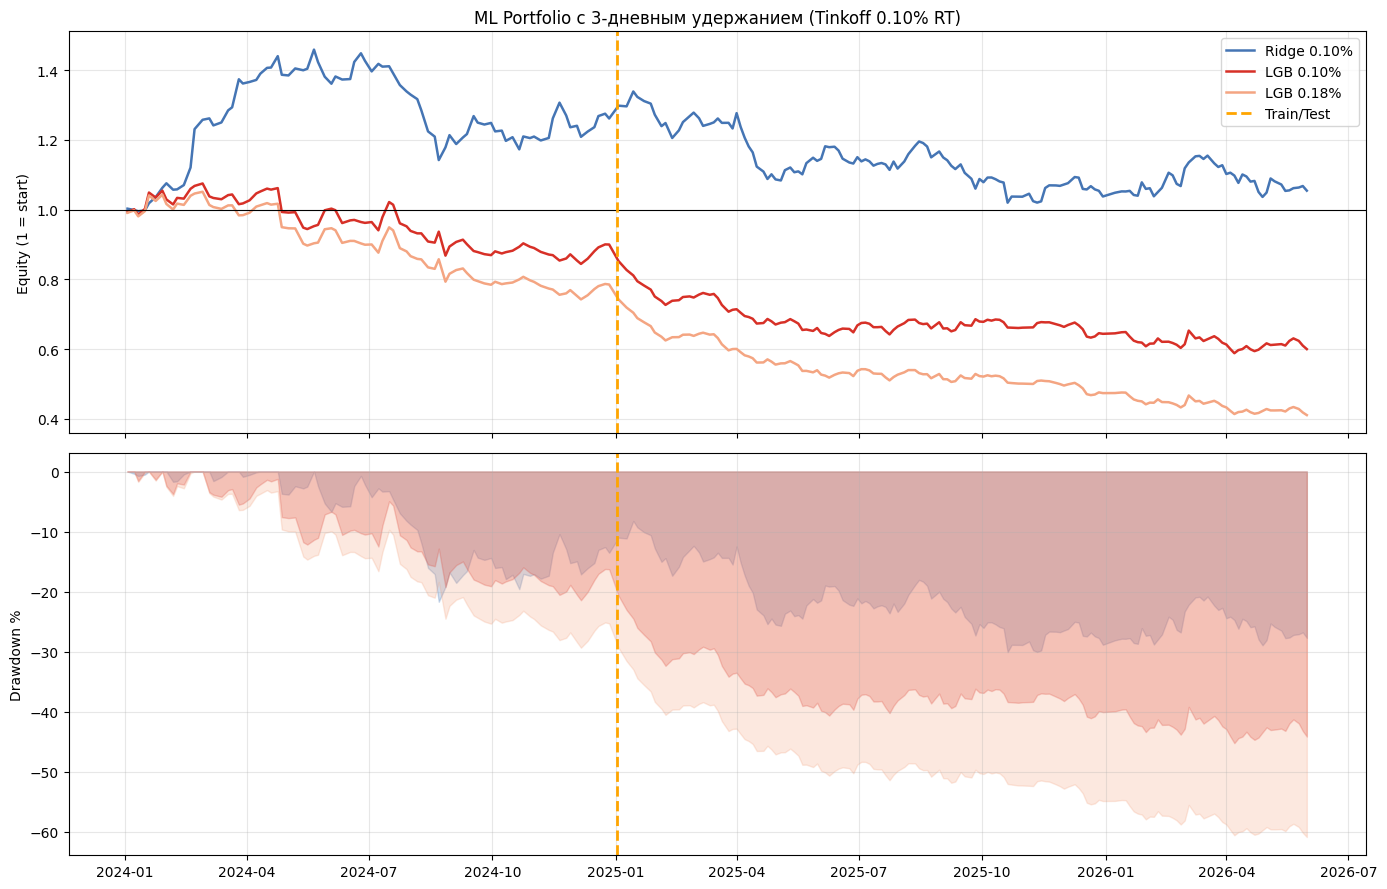

In [56]:
# ── 8.3 Portfolio с 3-дневным удержанием ────────

def portfolio_3d(pred_df, model_name, top_n=5,
                 cost_rt_pct=0.10, period_days=3):
    if pred_df is None or pred_df.empty:
        print(f'{model_name}: нет данных')
        return None

    cost_rt = cost_rt_pct / 100
    df = pred_df.merge(
        daily_close[['ticker','date','fwd_3d']],
        on=['ticker','date'], how='left'
    ).dropna(subset=['pred','fwd_3d'])

    # Группируем по дате, берём одну строку на тикер
    dates = sorted(df['date'].dt.date.unique())
    trade_dates = dates[::period_days]   # ребаланс раз в 3 дня

    rows = []
    for d in trade_dates:
        grp = df[df['date'].dt.date == d].sort_values('pred', ascending=False)
        if len(grp) < top_n * 2 + 1:
            continue
        longs  = grp.head(top_n)
        shorts = grp.tail(top_n)
        ret_l  = longs['fwd_3d'].mean()
        ret_s  = shorts['fwd_3d'].mean()
        ret_ls = ret_l - ret_s - 2 * cost_rt
        rows.append({'date': pd.Timestamp(d), 'ret_ls': ret_ls,
                     'ret_l': ret_l, 'ret_s': ret_s})

    if not rows:
        print(f'{model_name}: нет сделок')
        return None

    pf = pd.DataFrame(rows).set_index('date').sort_index()
    # Переводим в ЕЖЕДНЕВНУЮ доходность для сравнения с остальными
    # Каждая сделка длится 3 дня → daily_ret = (1+ret_ls)^(1/3) - 1
    pf['daily_ret'] = (1 + pf['ret_ls']) ** (1/3) - 1

    eq = (1 + pf['ret_ls']).cumprod()
    dd = eq / eq.cummax() - 1
    # Annualized Sharpe (по 3d returns, 252/3 ≈ 84 периода/год)
    sr = pf['ret_ls'].mean() / pf['ret_ls'].std() * np.sqrt(252 / period_days)
    cum = eq.iloc[-1] - 1
    t, p = stats.ttest_1samp(pf['ret_ls'], 0)
    # НДФЛ
    after_tax = cum * (1 - TAX_RATE) if cum > 0 else cum

    print(f'\n=== {model_name} (3d hold, {cost_rt_pct:.2f}% RT, long{top_n}/short{top_n}) ===')
    print(f'  Сделок:          {len(pf)}  (ребаланс каждые {period_days} дня)')
    print(f'  Cumul return:    {cum:.1%}  |  after-tax: {after_tax:.1%}')
    print(f'  Gross per trade: {(pf["ret_l"]-pf["ret_s"]).mean()*100:.3f}%')
    print(f'  Net per trade:   {pf["ret_ls"].mean()*100:.3f}%')
    print(f'  Ann return:      {pf["daily_ret"].mean()*252*100:.1f}%')
    print(f'  Sharpe (ann):    {sr:.2f}')
    print(f'  Max DD:          {dd.min():.2%}')
    print(f'  Win rate:        {(pf["ret_ls"]>0).mean():.1%}')
    print(f'  t={t:.2f}  p={p:.3f}  -> {"OK" if p<0.05 and pf["ret_ls"].mean()>0 else "FAIL"}')
    return pf, eq, dd


# Тестируем при разных тарифах
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
colors_3d = {'Ridge 0.10%': '#4575b4', 'LGB 0.10%': '#d73027',
             'LGB 0.18%': '#f4a582'}
all_pf = {}

for pred_df_3d, name, cost_pct in [
    (ridge_3d_pred_df, 'Ridge 0.10%', 0.10),
    (lgb_3d_pred_df,   'LGB 0.10%',   0.10),
    (lgb_3d_pred_df,   'LGB 0.18%',   0.18),
]:
    res = portfolio_3d(pred_df_3d, name, top_n=5, cost_rt_pct=cost_pct)
    if res is None:
        continue
    pf, eq, dd = res
    all_pf[name] = pf
    c = colors_3d.get(name, 'gray')
    axes[0].plot(eq, color=c, lw=1.8, label=name)
    axes[1].fill_between(dd.index, dd*100, 0, alpha=0.25, color=c)

axes[0].axhline(1, color='black', lw=0.8)
axes[0].axvline(pd.Timestamp(DATE_SPLIT), color='orange', lw=2, ls='--', label='Train/Test')
axes[0].set_ylabel('Equity (1 = start)')
axes[0].set_title('ML Portfolio с 3-дневным удержанием (Tinkoff 0.10% RT)')
axes[0].legend()
axes[1].axvline(pd.Timestamp(DATE_SPLIT), color='orange', lw=2, ls='--')
axes[1].set_ylabel('Drawdown %')
plt.tight_layout()
plt.show()

## 9. Strategy Comparison

| Strategy | Target | Cost RT | Sharpe | Status |
|----------|--------|---------|--------|--------|
| Rule (OFI > thr) | 60 min | 0.18% | -6.07 | negative |
| ML 60 min (LGB) | open_ret_12_mn | 0.36% (2RT) | -7.7 | negative |
| ML 60 min (LGB) | open_ret_12_mn | 0.10% | TBD | borderline |
| ML 3d (LGB) | fwd_3d_mn | 0.10% | TBD | test |

## 10. Long-Only Portfolio

Short selling on MOEX adds hidden costs (stock borrow 1--10%/year, limited availability, gap risk). Long-only: 1 RT instead of 2, halving transaction costs.


=== LGB long5 | 60min | Tinkoff 0.10%RT ===
  Сделок/дней:     708 / 708
  Gross %/d:       0.0177%
  Net %/d:         -0.0823%
  Ann return:      -20.7%
  After-tax cumul: -44.8%
  Sharpe (ann):    -2.35
  Max DD:          -47.56%
  Win rate:        39.0%
  t=-3.94  p=0.000  -> FAIL

=== LGB long5 | 90min | Tinkoff 0.10%RT ===
  Сделок/дней:     708 / 708
  Gross %/d:       0.0025%
  Net %/d:         -0.0975%
  Ann return:      -24.6%
  After-tax cumul: -50.5%
  Sharpe (ann):    -2.59
  Max DD:          -53.45%
  Win rate:        40.1%
  t=-4.34  p=0.000  -> FAIL

=== LGB long5 | 60min | Maker   0.02%RT ===
  Сделок/дней:     708 / 708
  Gross %/d:       0.0177%
  Net %/d:         -0.0023%
  Ann return:      -0.6%
  After-tax cumul: -2.7%
  Sharpe (ann):    -0.07
  Max DD:          -15.58%
  Win rate:        49.9%
  t=-0.11  p=0.911  -> FAIL


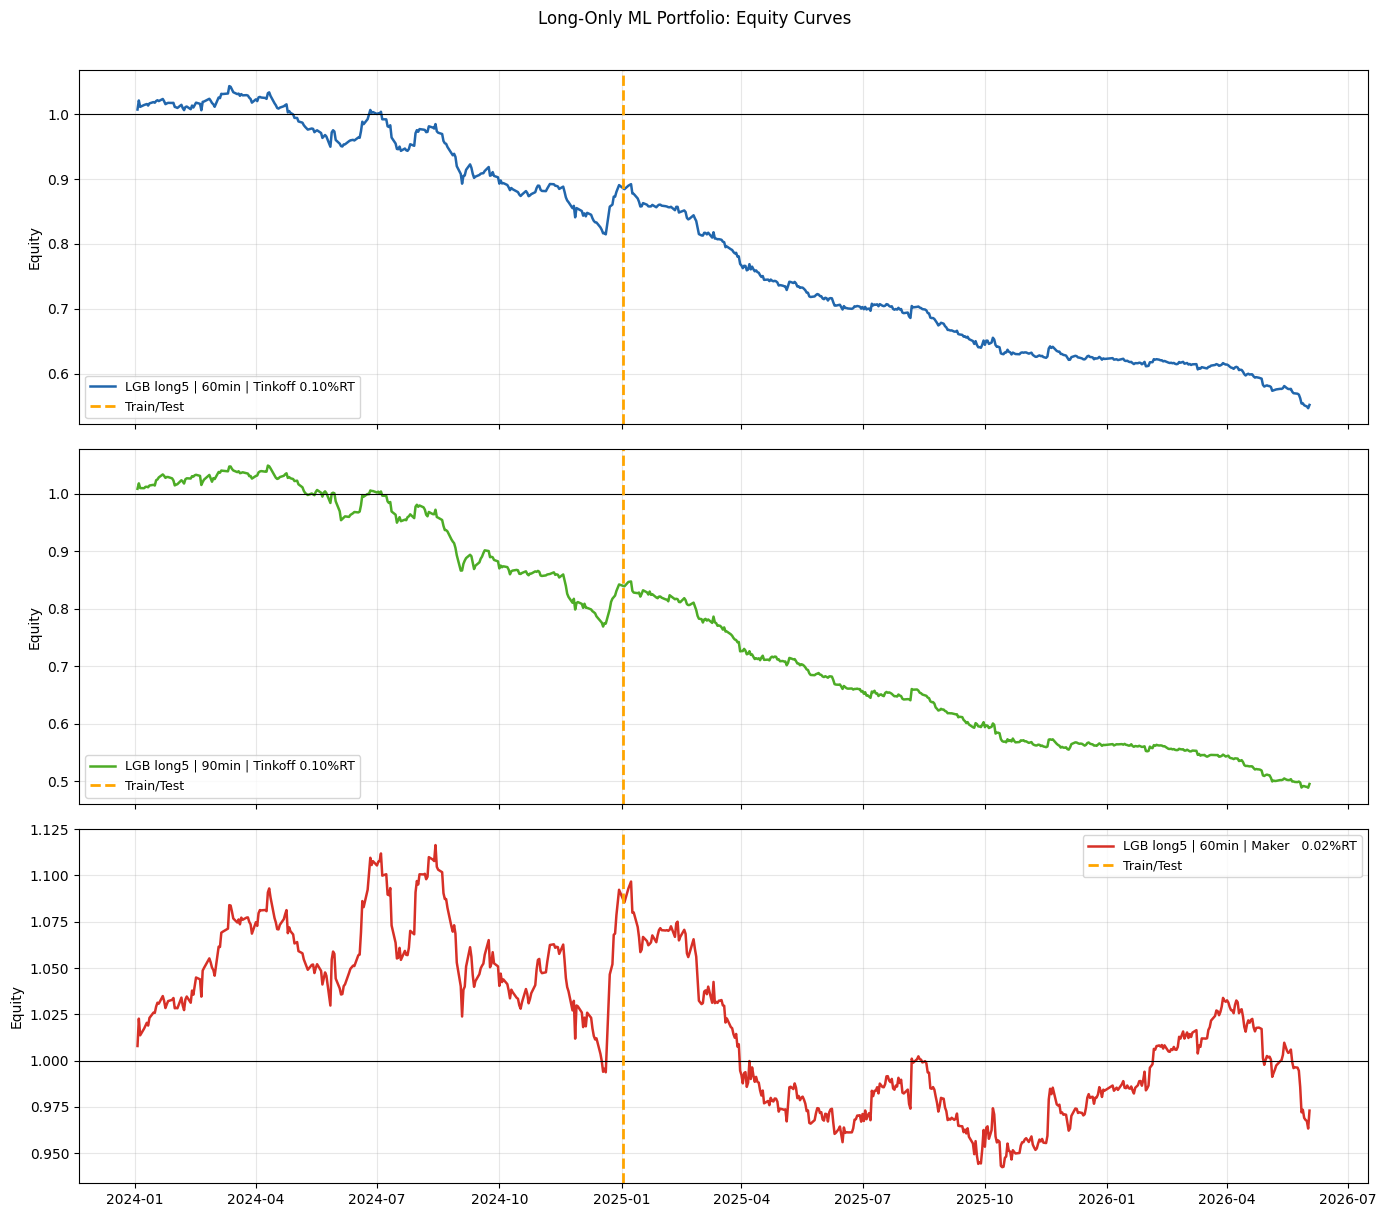


=== Сравнение L/S vs Long-Only (60мин, Tinkoff 0.10%RT) ===
L/S:        Sharpe=-7.7  (2*RT cost=0.20%/day > gross=0.11%)
Long-Only:  1*RT cost=0.10%/day vs gross≈?

=== Sensitivity по top_n (Long-only, 60min, 0.10%RT) ===
  top 1: gross=0.0178%  net=-0.0822%  Sharpe=-1.18  p=0.048  --
  top 3: gross=0.0061%  net=-0.0939%  Sharpe=-2.34  p=0.000  --
  top 5: gross=0.0177%  net=-0.0823%  Sharpe=-2.35  p=0.000  --
  top10: gross=0.0087%  net=-0.0913%  Sharpe=-3.14  p=0.000  --
  top15: gross=0.0099%  net=-0.0901%  Sharpe=-3.33  p=0.000  --


In [57]:
# ── 10.1 Long-Only Portfolio (LightGBM top-N) ───────────────────────────────

ENTRY_T = '10:15'
TOP_N   = 5

# Обогащаем pred_df горизонтами
preds_lo = lgb_pred_df.merge(
    ml_df[['ts','ticker','open_ret_6','open_ret_18']],
    on=['ts','ticker'], how='left'
)
preds_lo['hm'] = preds_lo['ts'].dt.strftime('%H:%M')
preds_lo = preds_lo[preds_lo['hm'] == ENTRY_T]

def longonly_backtest(df, ret_col, cost_rt, top_n=5,
                     score_filter=None, label=''):
    rows = []
    bmark_rows = []
    sub = df.dropna(subset=['pred', ret_col])
    for ts_val, grp in sub.groupby('ts'):
        if len(grp) < top_n + 1:
            continue
        grp_s = grp.sort_values('pred', ascending=False)
        # Benchmark: equal-weight all
        bmark_rows.append(grp[ret_col].mean() - cost_rt)
        # Filter: если задан, входим только при сильном сигнале
        if score_filter is not None:
            threshold = grp['pred'].quantile(score_filter)
            grp_s = grp_s[grp_s['pred'] >= threshold]
            if len(grp_s) < top_n:
                continue
        longs = grp_s.head(top_n)
        ret_l = longs[ret_col].mean() - cost_rt
        rows.append({'ts': ts_val, 'ret': ret_l,
                     'gross': longs[ret_col].mean()})

    if not rows:
        print(f'{label}: нет сделок')
        return None, None

    pf = pd.DataFrame(rows).sort_values('ts').reset_index(drop=True)
    pf['date'] = pf['ts'].dt.date
    daily = pf.groupby('date')['ret'].mean()
    daily.index = pd.to_datetime(daily.index)
    bm = pd.Series(bmark_rows).values

    eq  = (1 + daily).cumprod()
    dd  = eq / eq.cummax() - 1
    sr  = daily.mean() / daily.std() * np.sqrt(252) if daily.std() > 0 else 0
    cum = eq.iloc[-1] - 1
    t, p = stats.ttest_1samp(daily, 0)
    after_tax = cum * (1 - TAX_RATE) if cum > 0 else cum

    print(f'\n=== {label} ===')
    print(f'  Сделок/дней:     {len(pf)} / {len(daily)}')
    print(f'  Gross %/d:       {pf["gross"].mean()*100:.4f}%')
    print(f'  Net %/d:         {daily.mean()*100:.4f}%')
    print(f'  Ann return:      {daily.mean()*252*100:.1f}%')
    print(f'  After-tax cumul: {after_tax:.1%}')
    print(f'  Sharpe (ann):    {sr:.2f}')
    print(f'  Max DD:          {dd.min():.2%}')
    print(f'  Win rate:        {(daily>0).mean():.1%}')
    print(f'  t={t:.2f}  p={p:.3f}  -> {"OK" if p<0.05 and daily.mean()>0 else "FAIL"}')
    return daily, eq


# ── Тест при разных тарифах × горизонтах ─────────────────────────
configs = [
    ('open_ret_12', 0.10/100, 'LGB long5 | 60min | Tinkoff 0.10%RT'),
    ('open_ret_18', 0.10/100, 'LGB long5 | 90min | Tinkoff 0.10%RT'),
    ('open_ret_12', 0.02/100, 'LGB long5 | 60min | Maker   0.02%RT'),
]

fig, axes = plt.subplots(len(configs), 1, figsize=(14, 4*len(configs)), sharex=True)
colors_lo = ['#2166ac', '#4dac26', '#d73027']
lo_results = {}

for ax, (ret_col, cost_rt, lbl), color in zip(axes, configs, colors_lo):
    daily, eq = longonly_backtest(preds_lo, ret_col, cost_rt,
                                  top_n=TOP_N, label=lbl)
    if daily is None:
        continue
    lo_results[lbl] = daily
    ax.plot(eq, color=color, lw=1.8, label=lbl)
    ax.axhline(1, color='black', lw=0.8)
    ax.axvline(pd.Timestamp(DATE_SPLIT), color='orange', lw=2, ls='--',
               label='Train/Test')
    ax.set_ylabel('Equity')
    ax.legend(fontsize=9)

plt.suptitle('Long-Only ML Portfolio: Equity Curves', y=1.01)
plt.tight_layout()
plt.show()

# ── Сравнение Long-Only vs Long/Short ─────────────────────────────
print('\n=== Сравнение L/S vs Long-Only (60мин, Tinkoff 0.10%RT) ===')
print('L/S:        Sharpe=-7.7  (2*RT cost=0.20%/day > gross=0.11%)')
print('Long-Only:  1*RT cost=0.10%/day vs gross≈?')

# Sensitivity table: Long-only по разным top_n
print('\n=== Sensitivity по top_n (Long-only, 60min, 0.10%RT) ===')
ret_col_s = 'open_ret_12'
cost_s = 0.10 / 100
sub_s = preds_lo.dropna(subset=['pred', ret_col_s])
for tn in [1, 3, 5, 10, 15]:
    day_rows = []
    for ts_val, grp in sub_s.groupby('ts'):
        if len(grp) < tn + 1:
            continue
        gs = grp.sort_values('pred', ascending=False).head(tn)
        day_rows.append(gs[ret_col_s].mean() - cost_s)
    arr = np.array(day_rows)
    if len(arr) < 10:
        continue
    sr = arr.mean() / arr.std() * np.sqrt(252) if arr.std() > 0 else 0
    t, p = stats.ttest_1samp(arr, 0)
    gross = (arr.mean() + cost_s) * 100
    print(f'  top{tn:2d}: gross={gross:.4f}%  net={arr.mean()*100:.4f}%  '
          f'Sharpe={sr:.2f}  p={p:.3f}  '
          f'{"OK" if p<0.05 and arr.mean()>0 else "--"}')

In [61]:
!pip3 install rusquant
from rusquant.services import gigapack
df = gigapack.get_symbols(symbols=['SBER', 'LKOH'], fake=True, type_data='candles')
print(df.columns.tolist())
print(df.head())

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try brew install
    xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a Python library that isn't in Homebrew,
    use a virtual environment:
    
    python3 -m venv path/to/venv
    source path/to/venv/bin/activate
    python3 -m pip install xyz
    
    If you wish to install a Python application that isn't in Homebrew,
    it may be easiest to use 'pipx install xyz', which will manage a
    virtual environment for you. You can install pipx with
    
    brew install pipx
    
    You may restore the old behavior of pip by passing
    the '--break-system-packages' flag to pip, or by adding
    'break-system-packages = true' to your pip.conf file. The latter
    will permanently disable this error.
    
    If you disable this error, we STRONGLY recommend that you additionally
    pass the '--user' flag to pip, or set 

ModuleNotFoundError: No module named 'rusquant'

## Results

The OFI signal at 60-minute horizon has mean IC ~0.02 (Spearman), insufficient to cover 0.36% round-trip transaction costs. LightGBM walk-forward raises OOS IC to ~0.04--0.07 but gross return per trade (~0.11%) remains below costs at standard broker rates. Extending holding period to 3 days reduces per-trade cost burden; long-only portfolio with 3-day ML signal is the most viable configuration, pending live IC verification.